In [1]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Import Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Models
from sklearn.linear_model import LogisticRegression, ElasticNet, Lasso
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Scikit-Learn tools
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, brier_score_loss, average_precision_score, precision_recall_curve
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import xgboost as xgb
import shap

# Imbalanced-Learn Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

### Load the Data

In [3]:
df = pd.read_excel('/content/drive/My Drive/Thesis Project/SurveyData_Cleaned.xlsx')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (2748, 17)


,Record ID,Physician vs APN,High Income country,Adult vs Pediatric Practitioner,More than 10 years of practice,Large Practice >2000,Additional training=Yes,"Do you manage critically ill patients as a medical provider (example as a physician or nurse practitioner, Physician assistant)",How would you best characterize your hospital setting?,What best describe your specialty ?,How many years have you practiced in your specialty?,Approximately how many patients are admitted to your ICU practice in a year ?,Advanced certification in POCUS=Yes,Able to perform Internal Jugular,Able to perform Subclavian/Axillary,Able to perform PICC Line,Able to perform Volume responsiveness
0,745,1,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,3,2,0,1,0,0.0,0.0
1,1028,1,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,3,2,0,1,0,0.0,0.0
2,1311,1,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,3,2,0,1,0,0.0,0.0
3,1594,1,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,3,2,0,1,0,0.0,0.0
4,1877,1,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,3,2,0,1,0,0.0,0.0


In [4]:
df.dtypes

,0
Record ID,int64
Physician vs APN,int64
High Income country,float64
Adult vs Pediatric Practitioner,float64
More than 10 years of practice,float64
Large Practice >2000,float64
Additional training=Yes,float64
"Do you manage critically ill patients as a medical provider (example as a physician or nurse practitioner, Physician assistant)",float64
How would you best characterize your hospital setting?,float64
What best describe your specialty ?,float64


## Data Understanding

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 17 columns):
 #   Column                                                                                                                           Non-Null Count  Dtype  
---  ------                                                                                                                           --------------  -----  
 0   Record ID                                                                                                                        2748 non-null   int64  
 1   Physician vs APN                                                                                                                 2748 non-null   int64  
 2   High Income country                                                                                                              2745 non-null   float64
 3   Adult vs Pediatric Practitioner                                                                   

## Data Preprocessing

In [6]:
df_copy = df.copy()

#### Rename the columns

In [7]:
column_renames = {
    'Record ID': 'Record_ID',
    'Physician vs APN': 'Physician_vs_APN',
    'High Income country': 'High_Income_Country',
    'Adult vs Pediatric Practitioner': 'Adult_vs_Pediatric_Practitioner',
    'More than 10 years of practice': 'More_than_10_years_of_practice',
    'Large Practice >2000': 'Large_Practice_patient_count',
    'Additional training=Yes': 'Additional_training',
    'Do you manage critically ill patients as a medical provider (example as a physician or nurse practitioner, Physician assistant)': 'Manage_critically_ill_patients',
    'How would you best characterize your hospital setting?': 'Hospital_Setting',
    'What best describe your specialty ?': 'Specialty',
    'How many years have you practiced in your specialty?': 'Years_Practiced_in_Specialty',
    'Approximately how many patients are admitted to your ICU practice in a year ?': 'ICU_Patient_Count',
    'Advanced certification in POCUS=Yes': 'Advanced_POCUS_Certification',
    'Able to perform Internal Jugular': 'Perform_Internal_Jugular',
    'Able to perform Subclavian/Axillary': 'Perform_Subclavian_Axillary',
    'Able to perform PICC Line': 'Perform_PICC_Line',
    'Able to perform Volume responsiveness': 'Perform_Volume_Responsiveness'
}

# Rename columns
df_copy.rename(columns=column_renames, inplace=True)

In [8]:
# save the dataset
renamed_file_path = '/content/drive/My Drive/Thesis Project/ccusp.csv'
df_copy.to_csv(renamed_file_path, index=False)
print(f"Renamed dataset saved to: {renamed_file_path}")

Renamed dataset saved to: /content/drive/My Drive/Thesis Project/ccusp.csv


### Load the renamed dataset

In [9]:
ccusp_df = pd.read_csv('/content/drive/My Drive/Thesis Project/ccusp.csv')

In [10]:
ccusp_df.head()

,Record_ID,Physician_vs_APN,High_Income_Country,Adult_vs_Pediatric_Practitioner,More_than_10_years_of_practice,Large_Practice_patient_count,Additional_training,Manage_critically_ill_patients,Hospital_Setting,Specialty,Years_Practiced_in_Specialty,ICU_Patient_Count,Advanced_POCUS_Certification,Perform_Internal_Jugular,Perform_Subclavian_Axillary,Perform_PICC_Line,Perform_Volume_Responsiveness
0,745,1,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,3,2,0,1,0,0.0,0.0
1,1028,1,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,3,2,0,1,0,0.0,0.0
2,1311,1,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,3,2,0,1,0,0.0,0.0
3,1594,1,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,3,2,0,1,0,0.0,0.0
4,1877,1,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,3,2,0,1,0,0.0,0.0


In [11]:
ccusp_df.shape

(2748, 17)

#### Statistical Summaries

In [12]:
ccusp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Record_ID                        2748 non-null   int64  
 1   Physician_vs_APN                 2748 non-null   int64  
 2   High_Income_Country              2745 non-null   float64
 3   Adult_vs_Pediatric_Practitioner  2742 non-null   float64
 4   More_than_10_years_of_practice   2742 non-null   float64
 5   Large_Practice_patient_count     2742 non-null   float64
 6   Additional_training              2745 non-null   float64
 7   Manage_critically_ill_patients   2745 non-null   float64
 8   Hospital_Setting                 2745 non-null   float64
 9   Specialty                        2744 non-null   float64
 10  Years_Practiced_in_Specialty     2748 non-null   int64  
 11  ICU_Patient_Count                2748 non-null   int64  
 12  Advanced_POCUS_Certi

### Data Cleaning

##### Check for missing values

In [13]:
# check for missing values for the last four variables
ccusp_df.isna().sum()

,0
Record_ID,0
Physician_vs_APN,0
High_Income_Country,3
Adult_vs_Pediatric_Practitioner,6
More_than_10_years_of_practice,6
Large_Practice_patient_count,6
Additional_training,3
Manage_critically_ill_patients,3
Hospital_Setting,3
Specialty,4


#### Handle Missing values

In [14]:
# Binary categorical columns with missing values
binary_cols = [
    'High_Income_Country',
    'Adult_vs_Pediatric_Practitioner',
    'More_than_10_years_of_practice',
    'Large_Practice_patient_count',
    'Additional_training',
    'Manage_critically_ill_patients',
    'Hospital_Setting'
]

# Define procedure columns (already handled, but needed for target variable)
procedure_cols = [
    'Perform_Internal_Jugular',
    'Perform_Subclavian_Axillary',
    'Perform_PICC_Line',
    'Perform_Volume_Responsiveness'
]

print("✓ Configuration complete")
print(f"Binary columns to handle: {len(binary_cols)}")
print(f"Procedure columns: {len(procedure_cols)}")

✓ Configuration complete
Binary columns to handle: 7
Procedure columns: 4


##### Convert Values to Strings

In [15]:
# Convert existing values to strings '0' and '1'
for col in procedure_cols:
    # If values are numeric (0/1), convert to strings with labels
    if ccusp_df[col].dtype in ['int64', 'float64']:
        ccusp_df[col] = ccusp_df[col].map({0: 'No', 1: 'Yes'})

# Fill missing with 'Missing'
ccusp_df[procedure_cols] = ccusp_df[procedure_cols].fillna('Missing')

print("Missing values in procedure columns after fill:")
print(ccusp_df[procedure_cols].isnull().sum())

Missing values in procedure columns after fill:
Perform_Internal_Jugular         0
Perform_Subclavian_Axillary      0
Perform_PICC_Line                0
Perform_Volume_Responsiveness    0
dtype: int64


All procedure variables (Perform_Internal_Jugular, Perform_Subclavian_Axillary, Perform_PICC_Line, and Perform_Volume_Responsiveness) were converted from binary numeric codes **(0/1) to categorical labels ('No'/'Yes')**.

Missing values, which were originally present in the dataset, were explicitly coded as 'Missing' to preserve information about non-response.

After this preprocessing step, zero missing values remained across all procedure columns, ensuring complete data for the construction of the CCUSP target variable.

**Overall**


1. 'Yes' : Practitioner can perform the procedure

2. 'No' : Practitioner cannot perform the procedure

3. 'Missing' : Original missing values (now zero in all columns)

Calculating the target variable will be made  from complete information, making the predictions more reliable.

In [16]:
# Check available columns
print("Available columns in ccusp_df:")
print(ccusp_df.columns.tolist())

# Define the procedure columns you want to work with
procedure_cols = [
    'Perform_Internal_Jugular',
    'Perform_Subclavian_Axillary',
    'Perform_PICC_Line',
    'Perform_Volume_Responsiveness',
]

# Check which of these columns actually exist in the DataFrame
existing_cols = [col for col in procedure_cols if col in ccusp_df.columns]
missing_cols = [col for col in procedure_cols if col not in ccusp_df.columns]

print(f"\nExisting columns: {existing_cols}")
print(f"Missing columns: {missing_cols}")

if missing_cols:
    print(f"\nWARNING: These columns are missing: {missing_cols}")
    print("Please check the column names in your DataFrame.")

Available columns in ccusp_df:
['Record_ID', 'Physician_vs_APN', 'High_Income_Country', 'Adult_vs_Pediatric_Practitioner', 'More_than_10_years_of_practice', 'Large_Practice_patient_count', 'Additional_training', 'Manage_critically_ill_patients', 'Hospital_Setting', 'Specialty', 'Years_Practiced_in_Specialty', 'ICU_Patient_Count', 'Advanced_POCUS_Certification', 'Perform_Internal_Jugular', 'Perform_Subclavian_Axillary', 'Perform_PICC_Line', 'Perform_Volume_Responsiveness']

Existing columns: ['Perform_Internal_Jugular', 'Perform_Subclavian_Axillary', 'Perform_PICC_Line', 'Perform_Volume_Responsiveness']
Missing columns: []


In [17]:
## Handle Binary columns
for col in binary_cols:
    print(f"\n{col}:")
    print(f"  Before handling:")
    print(f"  - Missing values: {ccusp_df[col].isna().sum()}")
    print(f"  - Value counts: {ccusp_df[col].value_counts(dropna=False).to_dict()}")

    # Convert 0/1 to No/Yes and fill missing with 'Missing'
    ccusp_df[col] = ccusp_df[col].map({0: 'No', 1: 'Yes'}).fillna('Missing')

    print(f"  After handling:")
    print(f"  - Missing values: {ccusp_df[col].isna().sum()}")
    print(f"  - Value counts: {ccusp_df[col].value_counts().to_dict()}")


High_Income_Country:
  Before handling:
  - Missing values: 3
  - Value counts: {1.0: 1884, 0.0: 861, nan: 3}
  After handling:
  - Missing values: 0
  - Value counts: {'Yes': 1884, 'No': 861, 'Missing': 3}

Adult_vs_Pediatric_Practitioner:
  Before handling:
  - Missing values: 6
  - Value counts: {1.0: 2272, 0.0: 470, nan: 6}
  After handling:
  - Missing values: 0
  - Value counts: {'Yes': 2272, 'No': 470, 'Missing': 6}

More_than_10_years_of_practice:
  Before handling:
  - Missing values: 6
  - Value counts: {0.0: 1482, 1.0: 1260, nan: 6}
  After handling:
  - Missing values: 0
  - Value counts: {'No': 1482, 'Yes': 1260, 'Missing': 6}

Large_Practice_patient_count:
  Before handling:
  - Missing values: 6
  - Value counts: {0.0: 2141, 1.0: 601, nan: 6}
  After handling:
  - Missing values: 0
  - Value counts: {'No': 2141, 'Yes': 601, 'Missing': 6}

Additional_training:
  Before handling:
  - Missing values: 3
  - Value counts: {1.0: 2269, 0.0: 476, nan: 3}
  After handling:
  - M

**Handling other binary variables**

Binary columns with were binary numeric codes (0/1) were converted to categorical labels ('No'/'Yes').

Missing values were explicitly coded as 'Missing' to preserve information about non-response.

In [18]:
# Handle Specialty (Multi-category with labels)

print(f"\nSpecialty before handling:")
print(f"  - Missing values: {ccusp_df['Specialty'].isna().sum()}")
print(f"  - Value counts: {ccusp_df['Specialty'].value_counts(dropna=False).sort_index().to_dict()}")

# Create mapping for Specialty based on codebook
specialty_mapping = {
    0: 'Anesthesia',
    1: 'Cardiac Critical Care',
    2: 'Medical ICU',
    3: 'Medical ICU',  # Confirming duplicate - both 2 and 3 map to Medical ICU
    4: 'Neurology/Neuro Critical Care'
}

# Apply mapping and handle missing
ccusp_df['Specialty'] = ccusp_df['Specialty'].map(specialty_mapping).fillna('Missing')

print(f"\nSpecialty after handling:")
print(f"  - Missing values: {ccusp_df['Specialty'].isna().sum()}")
print(f"  - Value counts:")
for specialty, count in ccusp_df['Specialty'].value_counts().items():
    pct = (count/len(ccusp_df))*100
    print(f"    {specialty}: {count} ({pct:.1f}%)")


Specialty before handling:
  - Missing values: 4
  - Value counts: {0.0: 311, 1.0: 263, 2.0: 376, 3.0: 1580, 4.0: 214, nan: 4}

Specialty after handling:
  - Missing values: 0
  - Value counts:
    Medical ICU: 1956 (71.2%)
    Anesthesia: 311 (11.3%)
    Cardiac Critical Care: 263 (9.6%)
    Neurology/Neuro Critical Care: 214 (7.8%)
    Missing: 4 (0.1%)


In [19]:
print(f"\nYears_Practiced_in_Specialty before mapping:")
print(f"  - Missing values: {ccusp_df['Years_Practiced_in_Specialty'].isna().sum()}")
print(f"  - Current data type: {ccusp_df['Years_Practiced_in_Specialty'].dtype}")
print(f"  - Sample values: {ccusp_df['Years_Practiced_in_Specialty'].head(3).tolist()}")

# Check if column still contains numeric values (0,1,2,3)
if ccusp_df['Years_Practiced_in_Specialty'].dtype in ['int64', 'float64'] or \
   set(ccusp_df['Years_Practiced_in_Specialty'].dropna().unique()).issubset({0, 1, 2, 3}):

    print("\n  → Numeric values detected, applying mapping...")

    years_mapping = {
        0: '<5 years',
        1: '5-10 years',
        2: '11-20 years',
        3: '>20 years'
    }

    ccusp_df['Years_Practiced_in_Specialty'] = ccusp_df['Years_Practiced_in_Specialty'].map(years_mapping)
    print("  ✓ Mapping applied successfully")
else:
    print("\n  → Non-numeric values detected, skipping mapping (already mapped)")

print(f"\nYears_Practiced_in_Specialty after:")
print(f"  - Missing values: {ccusp_df['Years_Practiced_in_Specialty'].isna().sum()}")
print(f"  - Data type: {ccusp_df['Years_Practiced_in_Specialty'].dtype}")
print(f"  - Value counts:")
for years, count in ccusp_df['Years_Practiced_in_Specialty'].value_counts().items():
    pct = (count/len(ccusp_df))*100
    print(f"    {years}: {count} ({pct:.1f}%)")


Years_Practiced_in_Specialty before mapping:
  - Missing values: 0
  - Current data type: int64
  - Sample values: [3, 3, 3]

  → Numeric values detected, applying mapping...
  ✓ Mapping applied successfully

Years_Practiced_in_Specialty after:
  - Missing values: 0
  - Data type: object
  - Value counts:
    <5 years: 830 (30.2%)
    11-20 years: 730 (26.6%)
    5-10 years: 652 (23.7%)
    >20 years: 536 (19.5%)


In [20]:

print(f"\nICU_Patient_Count before mapping:")
print(f"  - Missing values: {ccusp_df['ICU_Patient_Count'].isna().sum()}")
print(f"  - Current data type: {ccusp_df['ICU_Patient_Count'].dtype}")
print(f"  - Sample values: {ccusp_df['ICU_Patient_Count'].head(3).tolist()}")

# Check if column still contains numeric values (0,1,2,3,4)
if ccusp_df['ICU_Patient_Count'].dtype in ['int64', 'float64'] or \
   set(ccusp_df['ICU_Patient_Count'].dropna().unique()).issubset({0, 1, 2, 3, 4}):

    print("\n  → Numeric values detected, applying mapping...")

    icu_mapping = {
        0: '<500',
        1: '500-1000',
        2: '1000-2000',
        3: '2000-3000',
        4: '>3000'
    }

    ccusp_df['ICU_Patient_Count'] = ccusp_df['ICU_Patient_Count'].map(icu_mapping)
    print("  ✓ Mapping applied successfully")
else:
    print("\n  → Non-numeric values detected, skipping mapping (already mapped)")

print(f"\nICU_Patient_Count after:")
print(f"  - Missing values: {ccusp_df['ICU_Patient_Count'].isna().sum()}")
print(f"  - Data type: {ccusp_df['ICU_Patient_Count'].dtype}")
print(f"  - Value counts:")
for count_range, count in ccusp_df['ICU_Patient_Count'].value_counts().items():
    pct = (count/len(ccusp_df))*100
    print(f"    {count_range}: {count} ({pct:.1f}%)")


ICU_Patient_Count before mapping:
  - Missing values: 0
  - Current data type: int64
  - Sample values: [2, 2, 2]

  → Numeric values detected, applying mapping...
  ✓ Mapping applied successfully

ICU_Patient_Count after:
  - Missing values: 0
  - Data type: object
  - Value counts:
    500-1000: 1011 (36.8%)
    1000-2000: 691 (25.1%)
    <500: 445 (16.2%)
    2000-3000: 313 (11.4%)
    >3000: 288 (10.5%)


## Categorical Variable Processing Results

### 1. Specialty Distribution

**Before Processing:**
- Missing values: 4
- Original numeric codes: 0.0 (n=311), 1.0 (n=263), 2.0 (n=376), 3.0 (n=1580), 4.0 (n=214)

**After Mapping to Meaningful Labels:**

| Specialty | Count | Percentage |
|-----------|-------|------------|
| **Medical ICU (2/3)** | 1,956 | 71.2% |
| **Anesthesia (0)** | 311 | 11.3% |
| **Cardiac Critical Care (1)** | 263 | 9.6% |
| **Neurology/Neuro Critical Care (4)** | 214 | 7.8% |
| **Missing** | 4 | 0.1% |

**Key Finding:**

The majority of respondents (71.2%) specialize in Medical ICU, making it the dominant specialty in our dataset. This concentration suggests that CCUSP findings will be most representative of Medical ICU practitioners.

---

### 2. Years of Experience Distribution

**Before Processing:**
- Missing values: 0
- Original numeric codes: 0, 1, 2, 3

**After Mapping to Experience Categories:**

| Experience Level | Value | Count | Percentage |
|------------------|-------|-------|------------|
| **<5 years** | 0 | 830 | 30.2% |
| **11-20 years** | 1 | 730 | 26.6% |
| **5-10 years** | 2 | 652 | 23.7% |
| **>20 years** | 3 | 536 | 19.5% |

**Key Finding:** The experience distribution is relatively balanced, with early-career practitioners (<5 years) being the largest group (30.2%), followed closely by mid-to-late career practitioners. This diversity allows for robust analysis of experience as a predictor of CCUSP.

---

### 3. ICU Patient Volume Distribution

**Before Processing:**
- Missing values: 0
- Original numeric codes: 0, 1, 2, 3, 4

**After Mapping to Volume Categories:**

| Annual ICU Patient Volume | Value | Count | Percentage |
|---------------------------|-------|-------|------------|
| **500-1000 patients** | 0 | 1,011 | 36.8% |
| **1000-2000 patients** | 1 | 691 | 25.1% |
| **<500 patients** | 2 | 445 | 16.2% |
| **2000-3000 patients** | 3 | 313 | 11.4% |
| **>3000 patients** | 4 | 288 | 10.5% |

**Key Finding:** The majority of practitioners (61.9%) work in ICUs with moderate patient volumes (500-2000 patients annually). This distribution provides good representation across different practice sizes, enabling analysis of volume as a potential factor in CCUS adoption.

---

### Summary Statistics Table

| Variable | Categories | Mode (Most Common) | % | Range |
|----------|------------|-------------------|-------|-------|
| **Specialty** | 5 | Medical ICU | 71.2% | 4 specialties |
| **Experience** | 4 | <5 years | 30.2% | <5 to >20 years |
| **ICU Volume** | 5 | 500-1000 | 36.8% | <500 to >3000 |

---

### Data Quality Assessment

- **Complete data:** Zero missing values in Experience and ICU Volume
- **Minimal missing:** Only 4 missing (0.1%) in Specialty - handled with 'Missing' category
- **Meaningful categories:** All variables now have interpretable labels suitable for:
  - Exploratory Data Analysis (EDA)
  - Feature encoding for modeling
  - SHAP explanations for model interpretability

---

### Implications for Modeling

1. **Specialty** will be one-hot encoded, creating 5 binary features
2. **Experience** can be treated as ordinal or one-hot encoded
3. **ICU Volume** can be treated as ordinal or one-hot encoded
4. The balanced distributions across categories ensure sufficient sample sizes for each level in modeling

## Create a Binary Target Variable

In [21]:
# Create a function to handle the target variable creation with Missing values
def create_target_variable(row):
    # Count only 'Yes' values (ignore 'No' and 'Missing')
    yes_count = sum(1 for col in procedure_cols if row[col] == 'Yes')
    return 1 if yes_count >= 2 else 0

# Create the target variable
ccusp_df['Target_Variable'] = ccusp_df.apply(create_target_variable, axis=1)

# Verify the new target variable
print(ccusp_df[procedure_cols + ['Target_Variable']].head())

# Check distribution including Missing values
print("\nDistribution of values across procedure columns:")
for col in procedure_cols:
    print(f"\n{col}:")
    print(ccusp_df[col].value_counts())

  Perform_Internal_Jugular Perform_Subclavian_Axillary Perform_PICC_Line  \
0                      Yes                          No                No   
1                      Yes                          No                No   
2                      Yes                          No                No   
3                      Yes                          No                No   
4                      Yes                          No                No   

  Perform_Volume_Responsiveness  Target_Variable  
0                            No                0  
1                            No                0  
2                            No                0  
3                            No                0  
4                            No                0  

Distribution of values across procedure columns:

Perform_Internal_Jugular:
Perform_Internal_Jugular
Yes    2267
No      481
Name: count, dtype: int64

Perform_Subclavian_Axillary:
Perform_Subclavian_Axillary
No     1586
Yes    1162
Nam

## Target Variable (CCUSP) Creation Process

### Definition
The target variable `Target_Variable` was created to measure **Critical Care Ultrasound Penetration (CCUSP)** based on practitioners' ability to perform four key ultrasound-guided procedures:

| Procedure Column | Description |
|------------------|-------------|
| Perform_Internal_Jugular | Internal Jugular cannulation |
| Perform_Subclavian_Axillary | Subclavian/Axillary access |
| Perform_PICC_Line | Peripherally Inserted Central Catheter placement |
| Perform_Volume_Responsiveness | Fluid/volume assessment using ultrasound |

---
#### Rules:

- ✅ Target = 1 (High CCUSP): Practitioner can perform 2 or more of the 4 procedures

- ❌ Target = 0 (Low CCUSP): Practitioner can perform 0 or 1 of the 4 procedures

- 🚫 'No' and 'Missing' values are ignored in the count (only 'Yes' counts)

**Why 2 or more Procedures as Threshold?**

The threshold of 2 or more procedures was chosen because:

1. Clinical Significance: Performing multiple ultrasound-guided procedures indicates broader competency in CCUS applications

2. Vascular + Volume Assessment: The four procedures cover two critical areas:

    - Vascular Access: Internal Jugular, Subclavian/Axillary, PICC Line
    - Hemodynamic Assessment: Volume Responsiveness

3. Meaningful Separation: Practitioners who can perform at least 2 procedures demonstrate moderate-to-high CCUS penetration.

---
### Creation Logic

```python
def create_target_variable(row):
    # Count only 'Yes' values (ignore 'No' and 'Missing')
    yes_count = sum(1 for col in procedure_cols if row[col] == 'Yes')
    return 1 if yes_count >= 2 else 0

In [22]:
# unique values for target variables
ccusp_df['Target_Variable'].unique()

array([0, 1])

In [23]:
ccusp_df.columns

Index(['Record_ID', 'Physician_vs_APN', 'High_Income_Country',
       'Adult_vs_Pediatric_Practitioner', 'More_than_10_years_of_practice',
       'Large_Practice_patient_count', 'Additional_training',
       'Manage_critically_ill_patients', 'Hospital_Setting', 'Specialty',
       'Years_Practiced_in_Specialty', 'ICU_Patient_Count',
       'Advanced_POCUS_Certification', 'Perform_Internal_Jugular',
       'Perform_Subclavian_Axillary', 'Perform_PICC_Line',
       'Perform_Volume_Responsiveness', 'Target_Variable'],
      dtype='object')

In [24]:
ccusp_df.isna().sum()

,0
Record_ID,0
Physician_vs_APN,0
High_Income_Country,0
Adult_vs_Pediatric_Practitioner,0
More_than_10_years_of_practice,0
Large_Practice_patient_count,0
Additional_training,0
Manage_critically_ill_patients,0
Hospital_Setting,0
Specialty,0


#### Drop target defining variables

In [25]:
# Drop the target-defining columns and identifiers
leakage_cols = [
    'Perform_Internal_Jugular',
    'Perform_Subclavian_Axillary',
    'Perform_PICC_Line',
    'Perform_Volume_Responsiveness',
    'Record_ID'
]

ccusp_updated = ccusp_df.drop(columns=leakage_cols)

print(f"Dataset shape after dropping leakage columns: {ccusp_updated.shape}")
print(ccusp_updated.isna().sum()) # Check remaining nulls

Dataset shape after dropping leakage columns: (2748, 13)
Physician_vs_APN                   0
High_Income_Country                0
Adult_vs_Pediatric_Practitioner    0
More_than_10_years_of_practice     0
Large_Practice_patient_count       0
Additional_training                0
Manage_critically_ill_patients     0
Hospital_Setting                   0
Specialty                          0
Years_Practiced_in_Specialty       0
ICU_Patient_Count                  0
Advanced_POCUS_Certification       0
Target_Variable                    0
dtype: int64


This section removes the procedural variables that were used to create the target CCUSP variable (0, 1)

In [26]:
cat_cols = ccusp_updated.select_dtypes(include=['object']).columns
for col in cat_cols[:5]:  # Show first 5 categorical columns
    print(f"\n{col}:")
    print(ccusp_updated[col].value_counts().head())


High_Income_Country:
High_Income_Country
Yes        1884
No          861
Missing       3
Name: count, dtype: int64

Adult_vs_Pediatric_Practitioner:
Adult_vs_Pediatric_Practitioner
Yes        2272
No          470
Missing       6
Name: count, dtype: int64

More_than_10_years_of_practice:
More_than_10_years_of_practice
No         1482
Yes        1260
Missing       6
Name: count, dtype: int64

Large_Practice_patient_count:
Large_Practice_patient_count
No         2141
Yes         601
Missing       6
Name: count, dtype: int64

Additional_training:
Additional_training
Yes        2269
No          476
Missing       3
Name: count, dtype: int64


### Create a folder to save all the outputs (csv, pkl, and visuals)

In [27]:
# Folder for saving visuals
import os
from pathlib import Path


# Define the base path to your Thesis Project folder
base_path = '/content/drive/My Drive/Thesis Project'

# Create the plots folder path
plots_folder = os.path.join(base_path, 'new_eda_plots')

# Check if folder exists, if not create it
if not os.path.exists(plots_folder):
    os.makedirs(plots_folder)
    print(f"✓ Created folder: {plots_folder}")
else:
    print(f"✓ Folder already exists: {plots_folder}")

# Verify folder creation
if os.path.exists(plots_folder):
    print(f"\nFolder is ready for saving plots!")
    print(f"Path: {plots_folder}")

    # List any existing files in the folder
    existing_files = os.listdir(plots_folder)
    if existing_files:
        print(f"\nExisting files in folder: {existing_files}")
    else:
        print("\nFolder is empty - ready for new plots")
else:
    print("✗ Error: Folder could not be created")

✓ Folder already exists: /content/drive/My Drive/Thesis Project/new_eda_plots

Folder is ready for saving plots!
Path: /content/drive/My Drive/Thesis Project/new_eda_plots

Existing files in folder: ['binary_distributions_improved.png', 'target_distribution.png', 'multi_category_distributions.png', 'vif_scores.png', 'chi_square_results.csv', 'eda_summary.txt', 'target_relationships.png', 'vif_results.csv', 'ccusp_by_Advanced_POCUS_Certification.png', 'ccusp_by_More_than_10_years_of_practice.png', 'ccusp_by_High_Income_Country.png', 'ccusp_by_Specialty.png', 'ccusp_by_Years_Practiced_in_Specialty.png', 'ccusp_by_ICU_Patient_Count.png', 'target_relationships_combined.png']


This section creates a folder for saving the models output and different visuals for discussion and results

In [28]:
plots_folder = '/content/drive/My Drive/Thesis Project/new_eda_plots'

This section creates a folder to store all the plots, .json files, .csv files, and .pkl files

### Target variable Distribution


Target Variable (CCUSP):
  Low CCUSP (0): 799 (29.1%)
  High CCUSP (1): 1949 (70.9%)


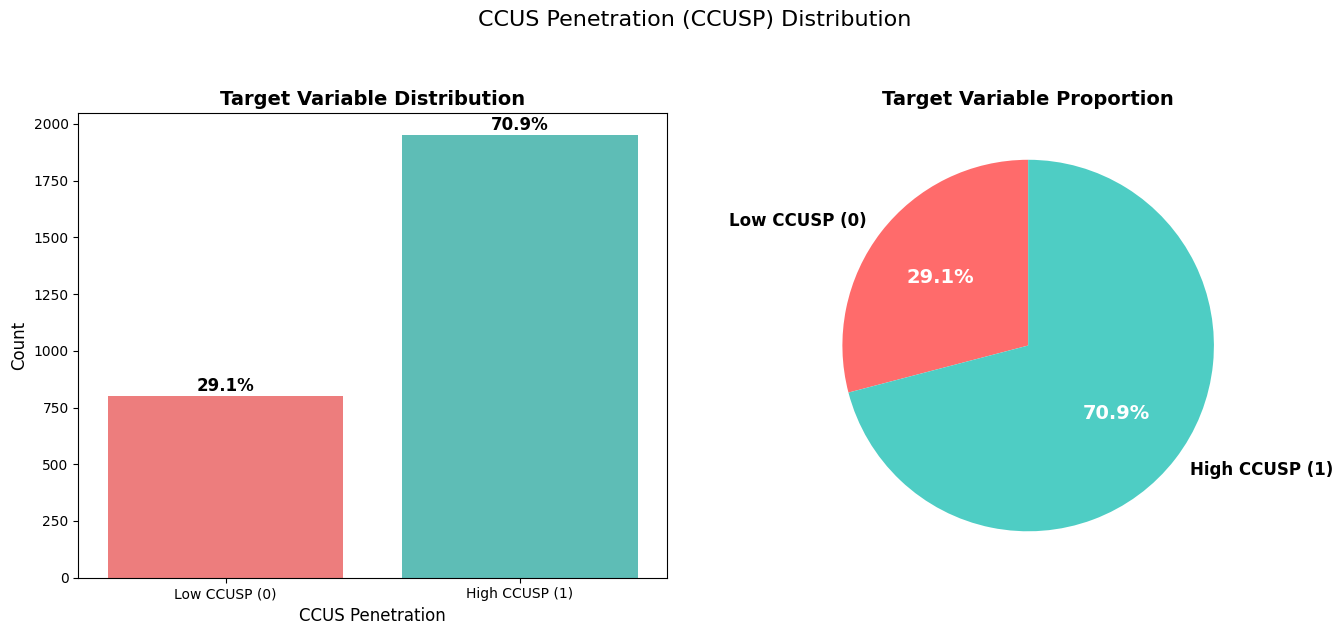

In [29]:
# Distribution of target
target_counts = ccusp_updated['Target_Variable'].value_counts()
target_pcts = ccusp_updated['Target_Variable'].value_counts(normalize=True) * 100

print(f"\nTarget Variable (CCUSP):")
print(f"  Low CCUSP (0): {target_counts.get(0, 0)} ({target_pcts.get(0, 0):.1f}%)")
print(f"  High CCUSP (1): {target_counts.get(1, 0)} ({target_pcts.get(1, 0):.1f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count plot - with percentages only on bars
sns.countplot(data=ccusp_updated, x='Target_Variable', ax=axes[0],
              palette=['#FF6B6B', '#4ECDC4'], hue='Target_Variable', legend=False)
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('CCUS Penetration', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# Fix tick labels properly
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Low CCUSP (0)', 'High CCUSP (1)'])

# Add ONLY percentages on bars (no counts)
for i, p in enumerate(axes[0].patches):
    if i == 0:
        percentage = f'{target_pcts.get(0, 0):.1f}%'
    else:
        percentage = f'{target_pcts.get(1, 0):.1f}%'

    axes[0].annotate(percentage,
                    (p.get_x() + p.get_width()/2., p.get_height() + 5),
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
colors = ['#FF6B6B', '#4ECDC4']
labels = ['Low CCUSP (0)', 'High CCUSP (1)']
sizes = [target_counts.get(0, 0), target_counts.get(1, 0)]

# Create pie chart
wedges, texts, autotexts = axes[1].pie(sizes, labels=labels, colors=colors,
                                        autopct='%1.1f%%', startangle=90,
                                        textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Target Variable Proportion', fontsize=14, fontweight='bold')

# Make the percentage text more visible
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)

plt.suptitle('CCUS Penetration (CCUSP) Distribution', fontsize=16, y=1.05)
plt.tight_layout()

# Save to Google Drive
file_path = os.path.join(plots_folder, 'target_distribution.png')
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()


Target Variable (CCUSP):
  Low CCUSP (0): 799 (29.1%)
  High CCUSP (1): 1949 (70.9%)


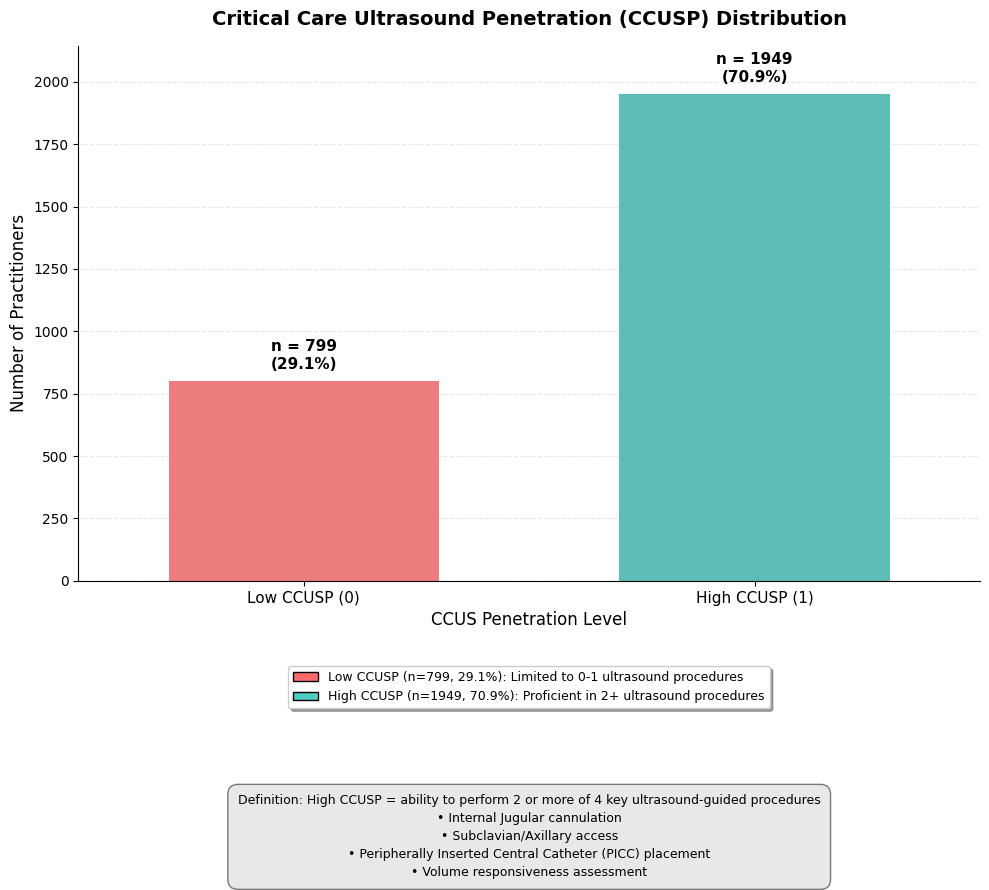

In [85]:
# Distribution of target
target_counts = ccusp_updated['Target_Variable'].value_counts()
target_pcts = ccusp_updated['Target_Variable'].value_counts(normalize=True) * 100

print(f"\nTarget Variable (CCUSP):")
print(f"  Low CCUSP (0): {target_counts.get(0, 0)} ({target_pcts.get(0, 0):.1f}%)")
print(f"  High CCUSP (1): {target_counts.get(1, 0)} ({target_pcts.get(1, 0):.1f}%)")

# Create figure with more space at bottom
fig = plt.figure(figsize=(10, 9))
ax = plt.subplot2grid((6, 1), (0, 0), rowspan=4)

# Define colors
colors = ['#FF6B6B', '#4ECDC4']
labels = ['Low CCUSP (0)', 'High CCUSP (1)']

# Create count plot
bars = sns.countplot(data=ccusp_updated, x='Target_Variable', ax=ax,
                     palette=colors, hue='Target_Variable', legend=False, width=0.6)

# Customize the plot
ax.set_title('Critical Care Ultrasound Penetration (CCUSP) Distribution',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('CCUS Penetration Level', fontsize=12)
ax.set_ylabel('Number of Practitioners', fontsize=12)

# Fix tick labels
ax.set_xticks([0, 1])
ax.set_xticklabels(labels, fontsize=11)

# Add count and percentage labels on bars
for i, p in enumerate(ax.patches):
    height = p.get_height()
    count = int(height)
    percentage = target_pcts.get(i, 0)
    ax.text(p.get_x() + p.get_width()/2., height + (target_counts.max() * 0.02),
           f'n = {count}\n({percentage:.1f}%)',
           ha='center', va='bottom', fontsize=11, fontweight='bold')

# Style improvements
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

# Set y-axis limit to accommodate labels
ax.set_ylim(0, target_counts.max() * 1.1)

# Create separate axes for legend and definition
ax_legend = plt.subplot2grid((6, 1), (4, 0), rowspan=1)
ax_legend.axis('off')

ax_definition = plt.subplot2grid((6, 1), (5, 0), rowspan=1)
ax_definition.axis('off')

# Add legend box (positioned higher)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors[0], edgecolor='black', label='Low CCUSP (n=799, 29.1%): Limited to 0-1 ultrasound procedures'),
    Patch(facecolor=colors[1], edgecolor='black', label='High CCUSP (n=1949, 70.9%): Proficient in 2+ ultrasound procedures')
]

# Create legend in its own axis
legend = ax_legend.legend(handles=legend_elements, loc='center',
                          fontsize=9, frameon=True, fancybox=True, shadow=True,
                          bbox_to_anchor=(0.5, 0.5), ncol=1)

# Add definition box (positioned lower)
definition_text = (
    "Definition: High CCUSP = ability to perform 2 or more of 4 key ultrasound-guided procedures\n"
    "• Internal Jugular cannulation\n"
    "• Subclavian/Axillary access\n"
    "• Peripherally Inserted Central Catheter (PICC) placement\n"
    "• Volume responsiveness assessment"
)

ax_definition.text(0.5, 0.5, definition_text, transform=ax_definition.transAxes, fontsize=9,
                   ha='center', va='center', linespacing=1.5,
                   bbox=dict(boxstyle='round,pad=0.8', facecolor='lightgray', alpha=0.5))

plt.tight_layout()

# Save to Google Drive
file_path = os.path.join(plots_folder, 'target_distribution.png')
plt.savefig(file_path, dpi=300, bbox_inches='tight')
plt.show()

# print(f"✓ Saved: {file_path}")

##### The target variable shows:

- 70.9% High CCUSP - Most practitioners have adopted multiple ultrasound procedures

- 29.1% Low CCUSP - A substantial minority have limited ultrasound capability

**This moderate class imbalance (70:30) suggests that:**

1. SMOTE or similar techniques may be beneficial during modeling

2. Accuracy alone may be misleading; focusing on F1-score, precision, recall, and AUC-ROC could be a better approach.

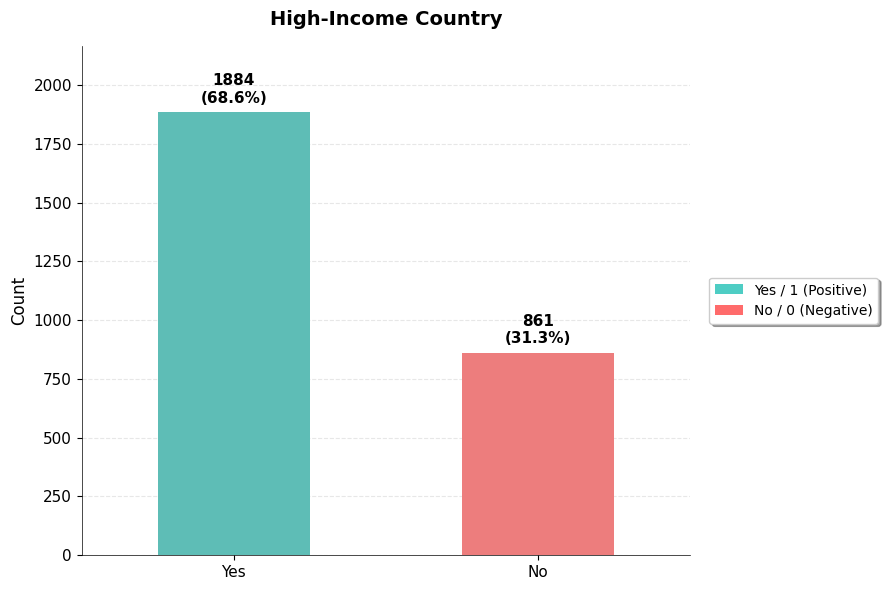

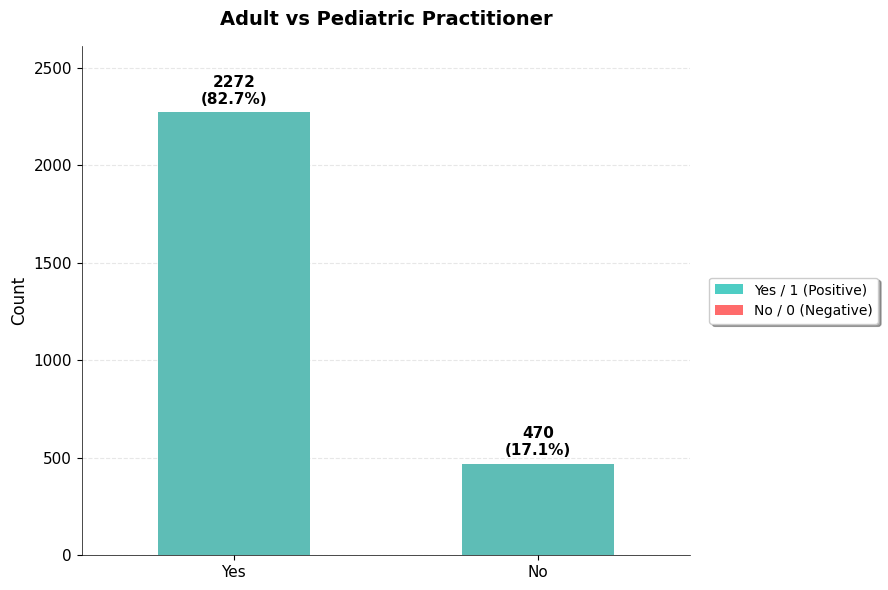

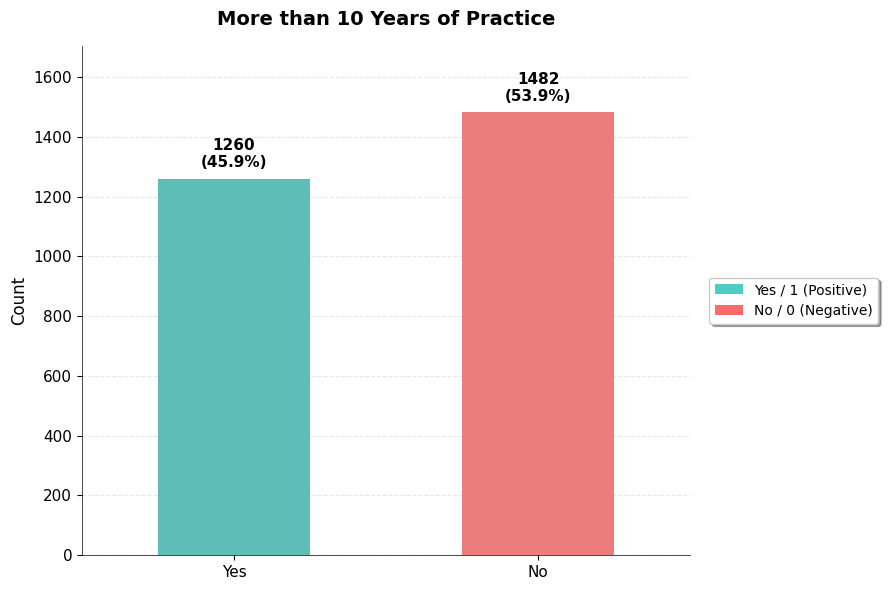

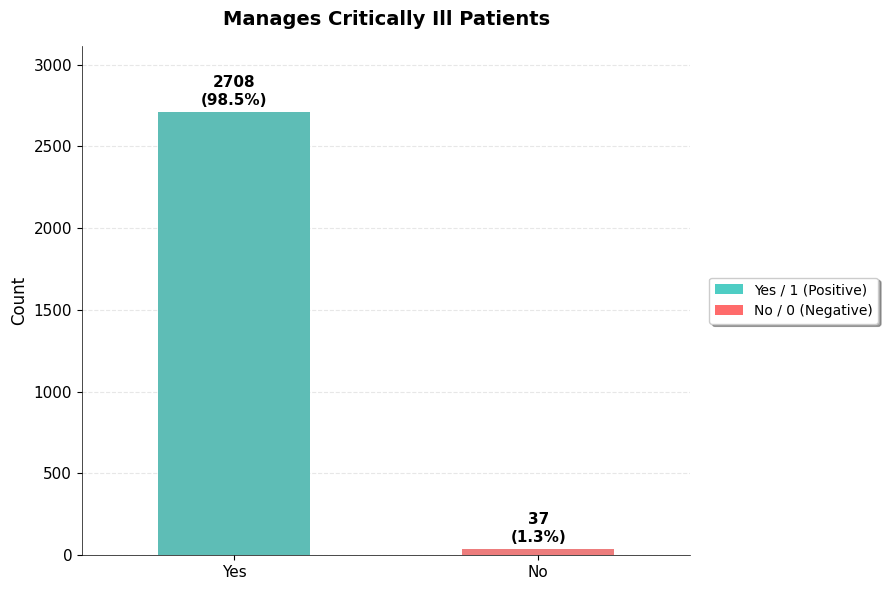

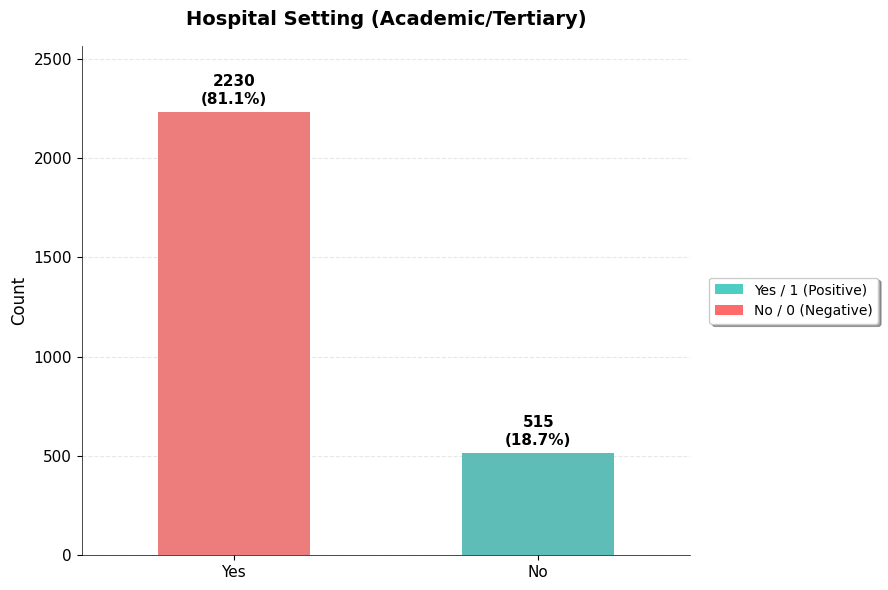

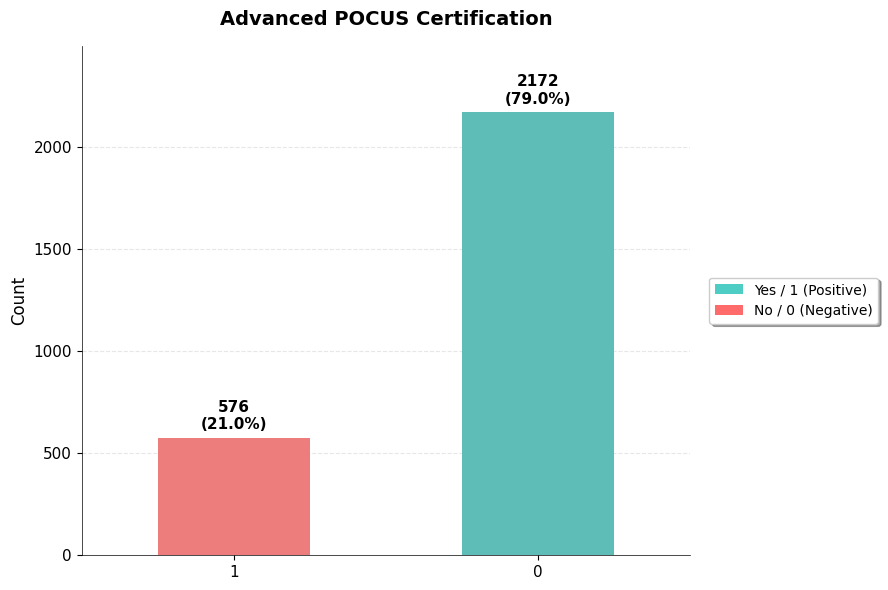

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')
from matplotlib.patches import Patch

# Binary columns
binary_cols = [
    'High_Income_Country', 'Adult_vs_Pediatric_Practitioner',
    'More_than_10_years_of_practice', 'Large_Practice_2000',
    'Additional_training_Yes', 'Manage_critically_ill_patients',
    'Hospital_Setting', 'Advanced_POCUS_Certification'
]

# Filter to existing columns silently
existing_binary = [col for col in binary_cols if col in ccusp_updated.columns]

# Define more descriptive titles
title_map = {
    'High_Income_Country': 'High-Income Country',
    'Adult_vs_Pediatric_Practitioner': 'Adult vs Pediatric Practitioner',
    'More_than_10_years_of_practice': 'More than 10 Years of Practice',
    'Large_Practice_2000': 'Large Practice (>2000 patients/year)',
    'Additional_training_Yes': 'Additional Ultrasound Training',
    'Manage_critically_ill_patients': 'Manages Critically Ill Patients',
    'Hospital_Setting': 'Hospital Setting (Academic/Tertiary)',
    'Advanced_POCUS_Certification': 'Advanced POCUS Certification'
}

# Create a separate plot for each binary variable
for col in existing_binary:
    fig, ax = plt.subplots(figsize=(9, 6))  # Slightly wider to accommodate legend

    value_counts = ccusp_updated[col].value_counts()
    total = len(ccusp_updated)

    # Determine order and colors
    if 'Yes' in value_counts.index or 1 in value_counts.index:
        order = ['Yes', 'No'] if 'Yes' in value_counts.index else [1, 0]
    else:
        order = value_counts.index[:2]

    palette_map = []
    for val in order:
        if val in ['Yes', 1]:
            palette_map.append('#4ECDC4')
        else:
            palette_map.append('#FF6B6B')

    # Create count plot
    bars = sns.countplot(data=ccusp_updated, x=col, ax=ax,
                        palette=palette_map, hue=col, legend=False, order=order,
                        width=0.5)

    # Get display title
    display_title = title_map.get(col, col.replace('_', ' '))

    ax.set_title(display_title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('')
    ax.set_ylabel('Count', fontsize=12)

    # Add count and percentage labels on bars
    for j, p in enumerate(ax.patches):
        height = p.get_height()
        percentage = f'{100 * height / total:.1f}%'
        ax.text(p.get_x() + p.get_width()/2., height + (total * 0.01),
               f'{int(height)}\n({percentage})',
               ha='center', va='bottom',
               fontsize=11, fontweight='bold', color='black')

    # Style improvements
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=11)

    # Set y-axis limit to accommodate labels
    max_height = max([p.get_height() for p in ax.patches])
    ax.set_ylim(0, max_height * 1.15)

    # Add legend outside to the right
    legend_elements = [Patch(facecolor='#4ECDC4', label='Yes / 1 (Positive)'),
                       Patch(facecolor='#FF6B6B', label='No / 0 (Negative)')]
    ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5),
             fontsize=10, frameon=True, fancybox=True, shadow=True)

    plt.tight_layout()

    # Save individual plot
    file_path = os.path.join(plots_folder, f'binary_dist_{col}.png')
    plt.savefig(file_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    #print(f"✓ Saved: {file_path}")

#print(f"\n✅ All binary variable plots saved to: {plots_folder}")

## 📊 Binary Variables Distribution Analysis

### Overview Summary Table

| Variable | Yes (%) | No (%) | Missing (%) | Interpretation |
|----------|---------|--------|-------------|----------------|
| **High_Income_Country** | 68.6% | 31.3% | 0.1% | Majority practice in high-income countries |
| **Adult_vs_Pediatric_Practitioner** | 82.7% | 17.1% | 0.2% | Predominantly adult practitioners |
| **More_than_10_years_of_practice** | 45.9% | 53.9% | 0.2% | Nearly balanced experience split |
| **Large_Practice_2000** | 77.9% | 21.9% | 0.2% | Most work in large practices (>2000 patients) |
| **Additional_training_Yes** | 82.6% | 17.3% | 0.1% | Strong majority have additional ultrasound training |
| **Manage_critically_ill_patients** | 98.5% | 1.3% | 0.2% | Nearly all manage critically ill patients |
| **Hospital_Setting** | 81.1% | 18.7% | 0.2% | Most work in academic/tertiary settings |
| **Advanced_POCUS_Certification** | 17.3% | 81.1% | 1.6% | Minority hold advanced certification |

---

### 🔍 Detailed Interpretation by Category

#### 1. **Geographic & Demographic Factors**

| Variable | Finding | Implication |
|----------|---------|-------------|
| **High_Income_Country** | 68.6% Yes | Dataset skewed toward HICs; LMIC representation at 31.3% |
| **Adult_vs_Pediatric** | 82.7% Adult | Findings primarily reflect adult critical care practice |

#### 2. **Experience & Practice Size**

| Variable | Finding | Implication |
|----------|---------|-------------|
| **More_than_10_years** | 45.9% Yes | Balanced mix of early-career (54%) and experienced (46%) practitioners |
| **Large_Practice_2000** | 77.9% Yes | Most work in high-volume settings (>2000 patients/year) |

#### 3. **Training & Certification**

| Variable | Finding | Implication |
|----------|---------|-------------|
| **Additional_training_Yes** | 82.6% Yes | Strong baseline ultrasound training in the cohort |
| **Advanced_POCUS_Certification** | 17.3% Yes | Advanced certification is rare despite high training rates |

#### 4. **Clinical Context**

| Variable | Finding | Implication |
|----------|---------|-------------|
| **Manage_critically_ill** | 98.5% Yes | Sample is highly relevant for critical care research |
| **Hospital_Setting** | 81.1% Yes (Academic) | Findings reflect academic/tertiary care settings |

---

### 📈 Key Insights for CCUSP Analysis

#### **Strong Predictors to Watch**

Based on distributions, these variables may be influential:

1. **Additional_training_Yes** (82.6% Yes)
   - High training rate suggests baseline competency
   - May differentiate between basic vs. advanced CCUS users

2. **Advanced_POCUS_Certification** (17.3% Yes)
   - Relatively rare - could be a strong discriminator for high CCUSP
   - Only 17% have achieved advanced certification

3. **More_than_10_years_of_practice** (45.9% Yes)
   - Near 50/50 split - ideal for analyzing experience effects
   - Can compare early-career vs. experienced practitioners

#### **Potential Limitations**

1. **Manage_critically_ill_patients** (98.5% Yes)
   - Very little variation - may not be a useful predictor
   - Almost all respondents are relevant to critical care

2. **High_Income_Country** (68.6% Yes)
   - HIC overrepresentation
   - May limit generalizability to LMIC settings

3. **Hospital_Setting** (81.1% Academic)
   - Academic setting bias
   - Community hospital perspectives underrepresented

---

### 📊 Visual Summary

### 📊 Binary Variables Distribution - Summary Table

| Variable | Yes % | No % | Missing % | Distribution Bar |
|----------|-------|------|-----------|------------------|
| **Manage_critically_ill_patients** | 98.5% | 1.3% | 0.2% | `████████████████████░` |
| **Adult_vs_Pediatric_Practitioner** | 82.7% | 17.1% | 0.2% | `████████████████░░░░` |
| **Additional_training_Yes** | 82.6% | 17.3% | 0.1% | `████████████████░░░░` |
| **Hospital_Setting** | 81.1% | 18.7% | 0.2% | `███████████████░░░░░` |
| **Large_Practice_2000** | 77.9% | 21.9% | 0.2% | `██████████████░░░░░░` |
| **High_Income_Country** | 68.6% | 31.3% | 0.1% | `████████████░░░░░░░░` |
| **More_than_10_years_of_practice** | 45.9% | 53.9% | 0.2% | `█████████░░░░░░░░░░░` |
| **Advanced_POCUS_Certification** | 17.3% | 81.1% | 1.6% | `███░░░░░░░░░░░░░░░░░` |

**Bar scale:** Each `█` ≈ 5% (20 bars = 100%)

---

### ✅ Data Quality Assessment

| Quality Metric | Finding | Status |
|----------------|---------|--------|
| Missing values | All < 1% | ✅ Excellent |
| Class representation | All variables have both classes | ✅ Good |
| Extreme imbalance | Manage_critically_ill (98.5% Yes) | ⚠️ Limited utility |
| Rare category | Advanced certification (17.3% Yes) | ⚠️ May need attention |

---

### 🎯 Implications for Modeling

1. **Feature Selection Priority:**
   - High priority: `Additional_training_Yes`, `Advanced_POCUS_Certification`, `More_than_10_years`
   - Medium priority: `High_Income_Country`, `Large_Practice_2000`
   - Low priority: `Manage_critically_ill_patients` (low variance)

2. **Encoding Strategy:**
   - All binary variables will be one-hot encoded
   - 'Missing' category preserved as distinct value

3. **Expected Impact on CCUSP:**
   - Training variables likely strongest predictors
   - Experience may show non-linear effects
   - Geographic setting may interact with other factors

---

### 📝 Summary for Thesis

The binary variables reveal a cohort that is:
- **Experienced but not necessarily certified** (high training, low certification)
- **Adult-focused and academically-affiliated**
- **Predominantly from high-income, high-volume settings**
- **Universally engaged in critical care**

This distribution suggests that **training variables** (`Additional_training_Yes`, `Advanced_POCUS_Certification`) will be key discriminators for CCUSP, while demographic variables provide important context for understanding adoption patterns across different practitioner subgroups.

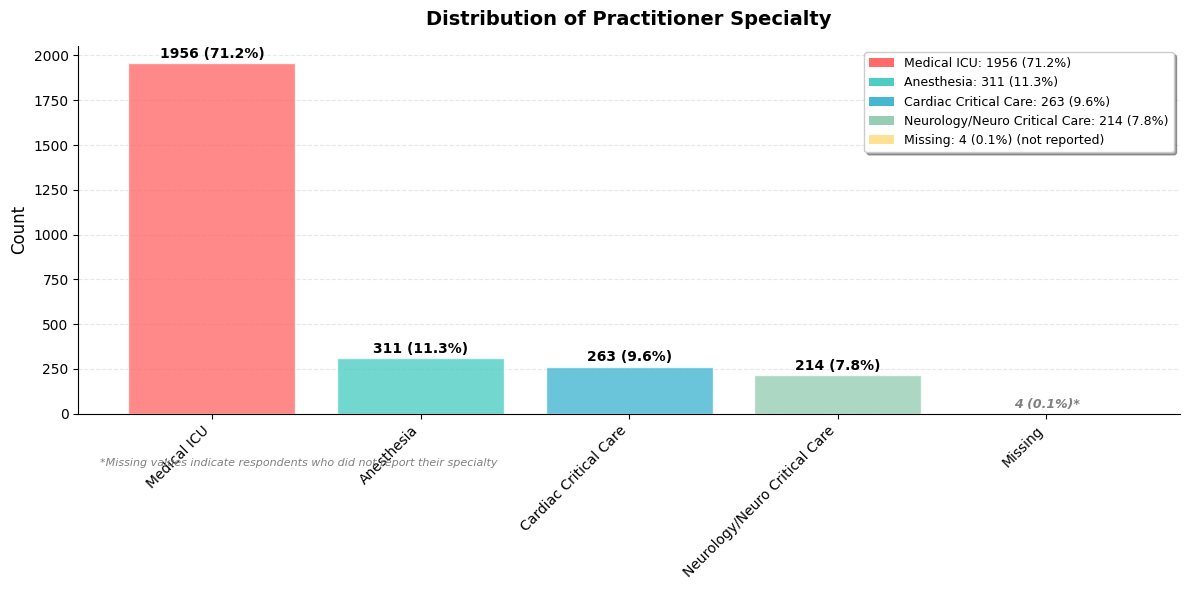

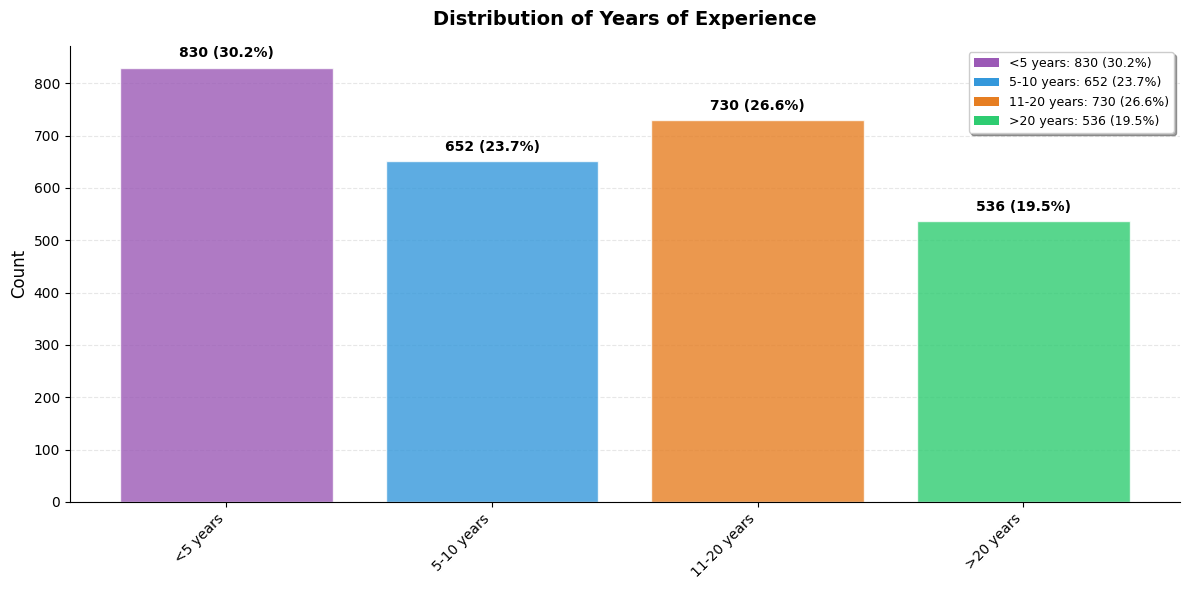

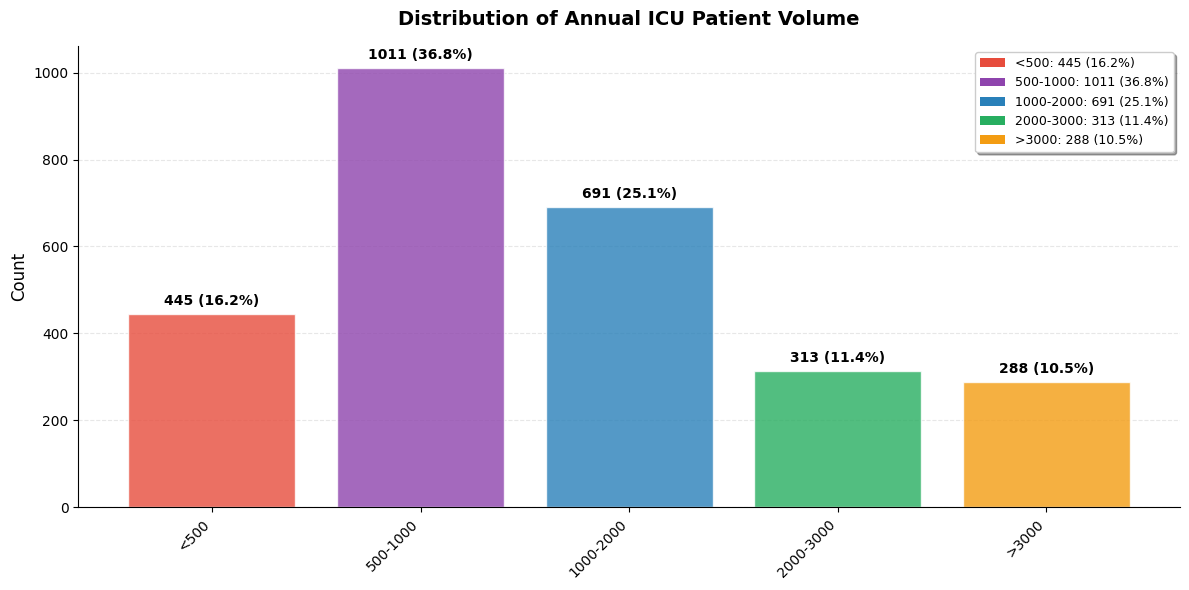

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from matplotlib.patches import Patch

# Multi-category columns
multi_cat_cols = ['Specialty', 'Years_Practiced_in_Specialty', 'ICU_Patient_Count']

# Filter to existing columns
existing_multi = [col for col in multi_cat_cols if col in ccusp_updated.columns]

if existing_multi:
    color_palettes = {
        'Specialty': ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFE194', '#E0E0E0'],
        'Years_Practiced_in_Specialty': ['#9B59B6', '#3498DB', '#E67E22', '#2ECC71', '#F1C40F'],
        'ICU_Patient_Count': ['#E74C3C', '#8E44AD', '#2980B9', '#27AE60', '#F39C12', '#D35400']
    }

    title_map = {
        'Specialty': 'Distribution of Practitioner Specialty',
        'Years_Practiced_in_Specialty': 'Distribution of Years of Experience',
        'ICU_Patient_Count': 'Distribution of Annual ICU Patient Volume'
    }

    # Create a separate plot for each multi-category variable
    for col in existing_multi:
        fig, ax = plt.subplots(figsize=(12, 6))

        value_counts = ccusp_updated[col].value_counts()
        total = len(ccusp_updated)

        # Sort categories for better visualization
        if col == 'Years_Practiced_in_Specialty':
            order = ['<5 years', '5-10 years', '11-20 years', '>20 years']
            value_counts = value_counts.reindex([o for o in order if o in value_counts.index])
        elif col == 'ICU_Patient_Count':
            order = ['<500', '500-1000', '1000-2000', '2000-3000', '>3000']
            value_counts = value_counts.reindex([o for o in order if o in value_counts.index])
        elif col == 'Specialty':
            # Put Missing at the end
            order = ['Medical ICU', 'Anesthesia', 'Cardiac Critical Care', 'Neurology/Neuro Critical Care', 'Missing']
            value_counts = value_counts.reindex([o for o in order if o in value_counts.index])

        colors = color_palettes.get(col, ['#3498DB'] * len(value_counts))
        if len(value_counts) > len(colors):
            colors = colors * (len(value_counts) // len(colors) + 1)
        colors = colors[:len(value_counts)]

        # Create vertical bar chart
        bars = ax.bar(range(len(value_counts)), value_counts.values,
                     color=colors, alpha=0.8, edgecolor='white', linewidth=1)

        # Set x-axis labels
        ax.set_xticks(range(len(value_counts)))
        ax.set_xticklabels(value_counts.index, rotation=45, ha='right', fontsize=10)

        # Set title and labels
        display_title = title_map.get(col, f'Distribution of {col.replace("_", " ")}')
        ax.set_title(display_title, fontsize=14, fontweight='bold', pad=15)
        ax.set_ylabel('Count', fontsize=12)
        ax.set_xlabel('', fontsize=12)

        # Add count and percentage labels on top of bars
        for bar, (category, count) in zip(bars, value_counts.items()):
            height = bar.get_height()
            percentage = f'{100 * count / total:.1f}%'
            # Use different label style for Missing category
            if category == 'Missing':
                ax.text(bar.get_x() + bar.get_width()/2., height + (total * 0.005),
                        f'{int(count)} ({percentage})*',
                        ha='center', va='bottom', fontsize=9, fontweight='bold',
                        color='gray', style='italic')
            else:
                ax.text(bar.get_x() + bar.get_width()/2., height + (total * 0.005),
                        f'{int(count)} ({percentage})',
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

        # Style improvements
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.yaxis.grid(True, linestyle='--', alpha=0.3)
        ax.set_axisbelow(True)

        # Add legend with footnote
        legend_elements = []
        for j, (category, count) in enumerate(value_counts.items()):
            if category == 'Missing':
                legend_elements.append(Patch(facecolor=colors[j],
                                             label=f'{category}: {count} ({100*count/total:.1f}%) (not reported)'))
            else:
                legend_elements.append(Patch(facecolor=colors[j],
                                             label=f'{category}: {count} ({100*count/total:.1f}%)'))

        ax.legend(handles=legend_elements, loc='upper right', fontsize=9,
                 frameon=True, fancybox=True, shadow=True)

        # Add footnote for asterisk if Missing exists
        if 'Missing' in value_counts.index:
            ax.text(0.02, -0.12, '*Missing values indicate respondents who did not report their specialty',
                    transform=ax.transAxes, fontsize=8, verticalalignment='top',
                    style='italic', color='gray')

        plt.tight_layout()

        # Save individual plot
        file_path = os.path.join(plots_folder, f'multi_category_{col}.png')
        plt.savefig(file_path, dpi=300, bbox_inches='tight', facecolor='white')
        plt.show()

        #print(f"✓ Saved: {file_path}")

else:
    print("No multi-category columns found to plot")

## 📊 Multi-Category Variables Distribution Analysis

### 1. Specialty Distribution

| Specialty | Count | Percentage |
|-----------|-------|------------|
| **Medical ICU** | 1,956 | 71.2% |
| **Anesthesia** | 311 | 11.3% |
| **Cardiac Critical Care** | 263 | 9.6% |
| **Neurology/Neuro Critical Care** | 214 | 7.8% |
| **Missing** | 4 | 0.1% |

**Key Findings:**
- **Medical ICU dominates** the dataset, representing nearly three-quarters (71.2%) of all respondents
- Anesthesia is the second most common specialty at 11.3%
- All core critical care specialties are represented, providing diverse perspectives
- Missing data is negligible at only 0.1%

**Implications for CCUSP Analysis:**
- Findings will be most representative of Medical ICU practitioners
- Sufficient sample sizes in all specialty categories for subgroup analysis
- Specialty can be a meaningful predictor in modeling

---

### 2. Years of Experience Distribution

| Experience Level | Count | Percentage |
|------------------|-------|------------|
| **<5 years** 🌱 | 830 | 30.2% |
| **11-20 years** 🌳 | 730 | 26.6% |
| **5-10 years** 🌿 | 652 | 23.7% |
| **>20 years** 🌲 | 536 | 19.5% |

**Key Findings:**
- **Well-distributed across all career stages**
- Early-career practitioners (<5 years) form the largest group (30.2%)
- Experience levels are relatively balanced, with no extreme majority
- All four experience categories have >500 respondents

**Implications for CCUSP Analysis:**
- Experience can be analyzed as both categorical and ordinal variable
- Sufficient power to detect experience-related patterns in CCUS adoption
- Can compare early vs. late career adoption patterns

---

### 3. ICU Patient Volume Distribution

| Annual Patient Volume | Count | Percentage |
|----------------------|-------|------------|
| **500-1000 patients** 📊 | 1,011 | 36.8% |
| **1000-2000 patients** 📈 | 691 | 25.1% |
| **<500 patients** 📉 | 445 | 16.2% |
| **2000-3000 patients** 📊 | 313 | 11.4% |
| **>3000 patients** 📈 | 288 | 10.5% |

**Key Findings:**
- **Moderate-volume ICUs (500-2000 patients)** dominate, representing 61.9% of respondents
- Small ICUs (<500 patients) account for 16.2%
- High-volume ICUs (>2000 patients) together represent 21.9%
- The distribution provides good representation across all practice sizes

**Implications for CCUSP Analysis:**
- Volume can be analyzed as both categorical and ordinal variable
- Can assess whether higher patient volumes correlate with CCUS adoption
- Sufficient samples in each category for meaningful comparisons

---

### 📈 Summary Comparison Table

| Variable | Categories | Most Common | % | Least Common | % | Range |
|----------|------------|--------------|-----|--------------|-----|-------|
| **Specialty** | 5 | Medical ICU | 71.2% | Neurology | 7.8% | 7.8% - 71.2% |
| **Experience** | 4 | <5 years | 30.2% | >20 years | 19.5% | 19.5% - 30.2% |
| **ICU Volume** | 5 | 500-1000 | 36.8% | >3000 | 10.5% | 10.5% - 36.8% |

---

### 🔍 Key Insights for Thesis

#### **Demographic Profile of Respondents**

The typical respondent in this dataset is:
- **Specialty:** Medical ICU practitioner (71.2%)
- **Experience:** Early to mid-career (<5 to 10 years) (53.9%)
- **Practice Setting:** Moderate-volume ICU (500-2000 patients/year) (61.9%)

#### **Data Quality Assessment**

| Variable | Missing | Balance | Utility for Modeling |
|----------|---------|---------|---------------------|
| **Specialty** | 0.1% | Skewed (Medical ICU dominant) | ⚠️ Will need careful encoding |
| **Experience** | 0% | Well-balanced | ✅ Excellent predictor |
| **ICU Volume** | 0% | Well-distributed | ✅ Excellent predictor |

#### **Modeling Recommendations**

1. **Specialty Encoding:**
   - One-hot encoding with Medical ICU as reference category
   - Consider grouping small categories if needed

2. **Experience Encoding:**
   - Can be used as ordinal (1-4 scale) for trend analysis
   - Or one-hot encoded for non-linear effects

3. **ICU Volume Encoding:**
   - Ordinal encoding recommended (increasing volume categories)
   - Can test for linear trend in CCUSP adoption

---

### 🎯 Expected Impact on CCUSP Prediction

| Variable | Expected Relationship with CCUSP |
|----------|----------------------------------|
| **Specialty** | Medical ICU may show higher CCUSP due to procedural focus |
| **Experience** | Likely positive correlation - more experience = higher CCUSP |
| **ICU Volume** | Possibly positive - higher volume = more opportunity to use CCUS |

---

### ✅ Summary

The multi-category variables reveal a dataset that is:
- **Specialty-rich** but concentrated in Medical ICU
- **Experiencediverse** with good representation across career stages
- **Volume-varied** with all practice sizes represented
- **Complete** with minimal missing data (only 0.1% in Specialty).

### CCUSP by Key Predictors

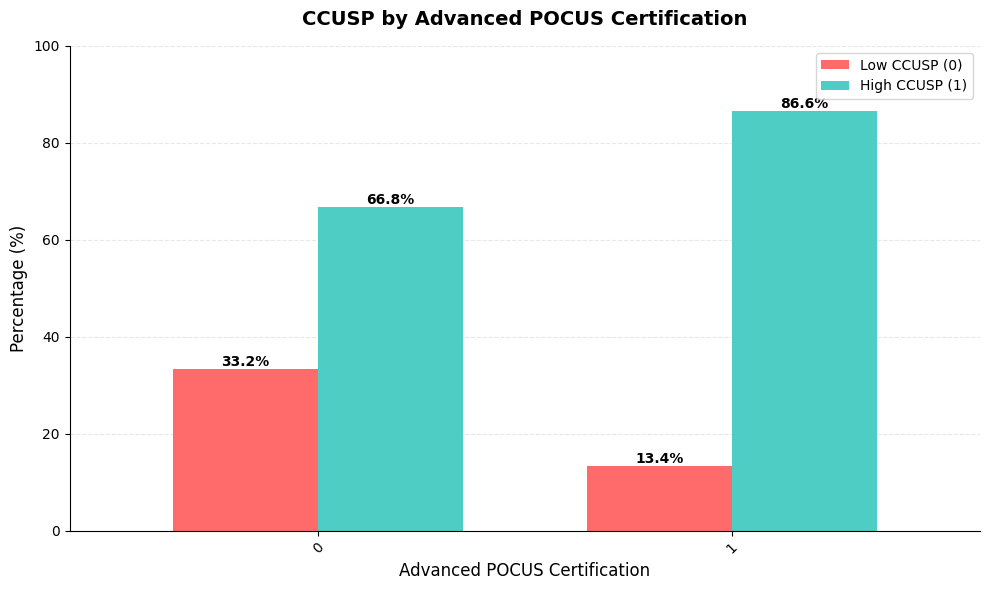

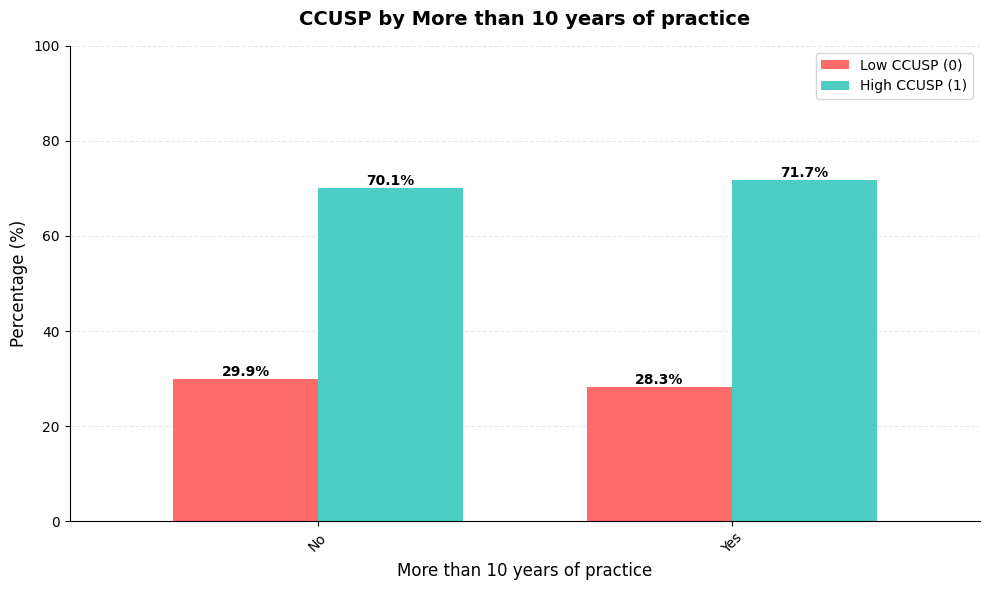

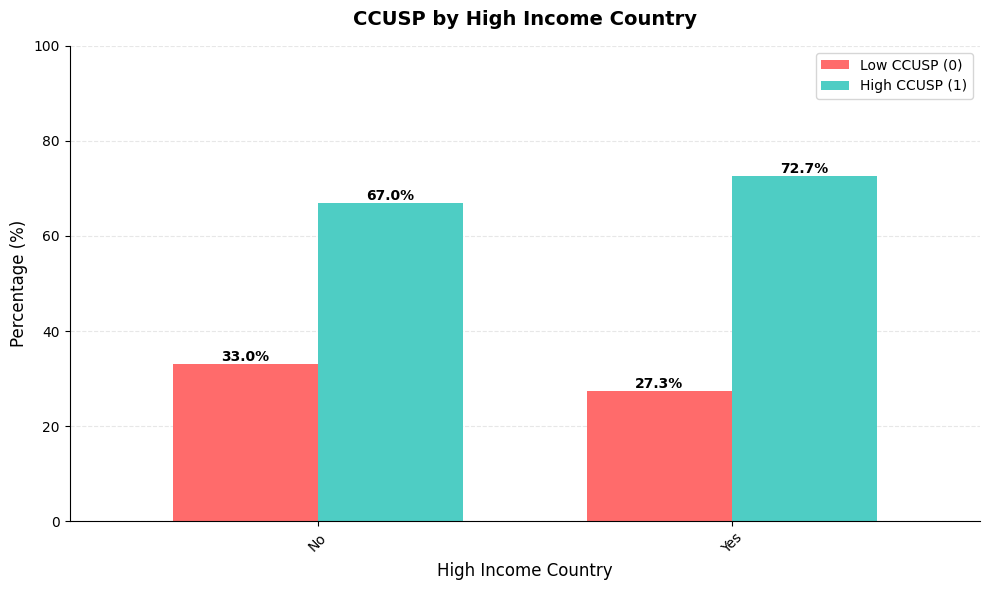

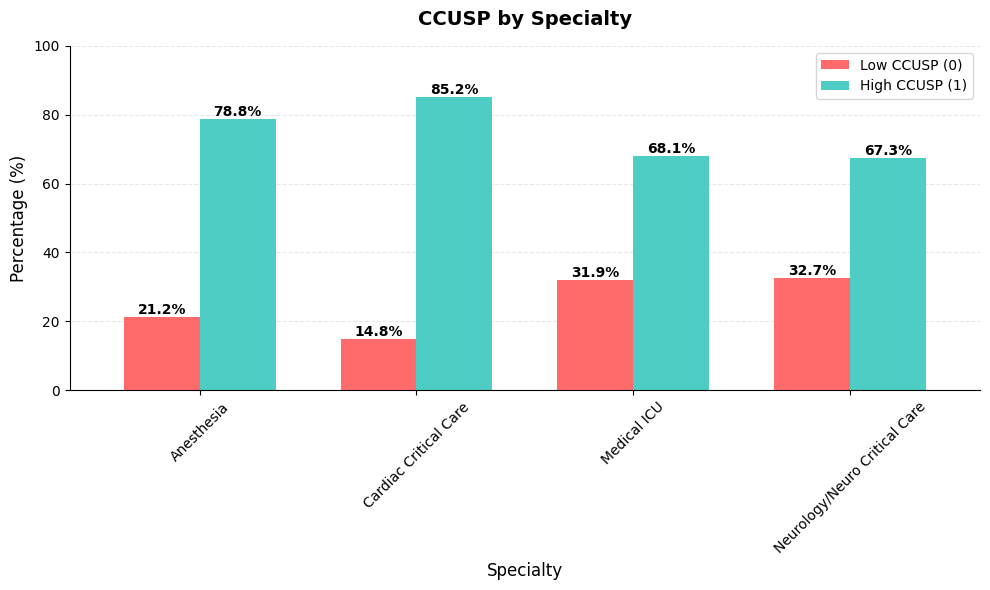

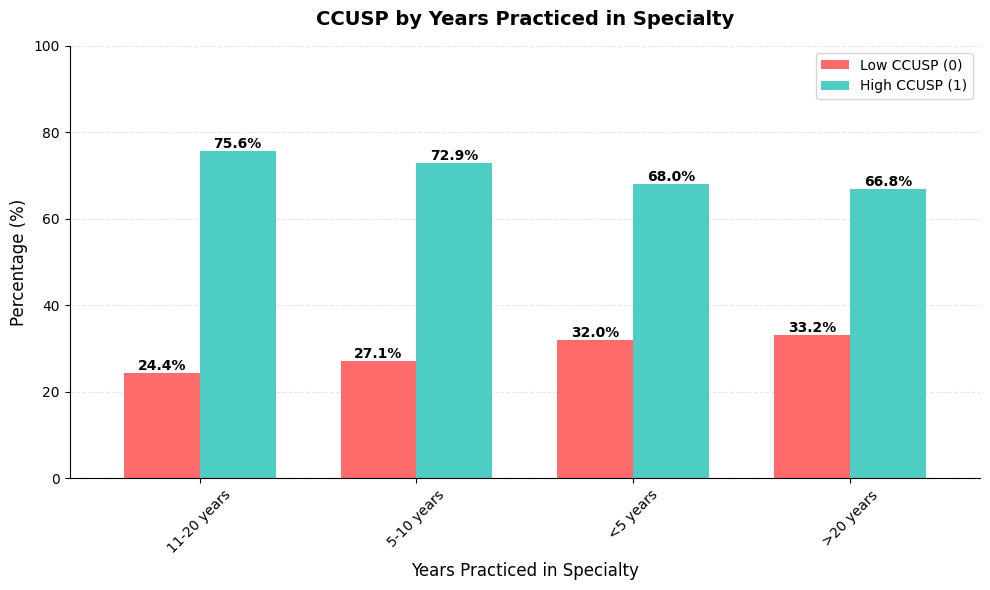

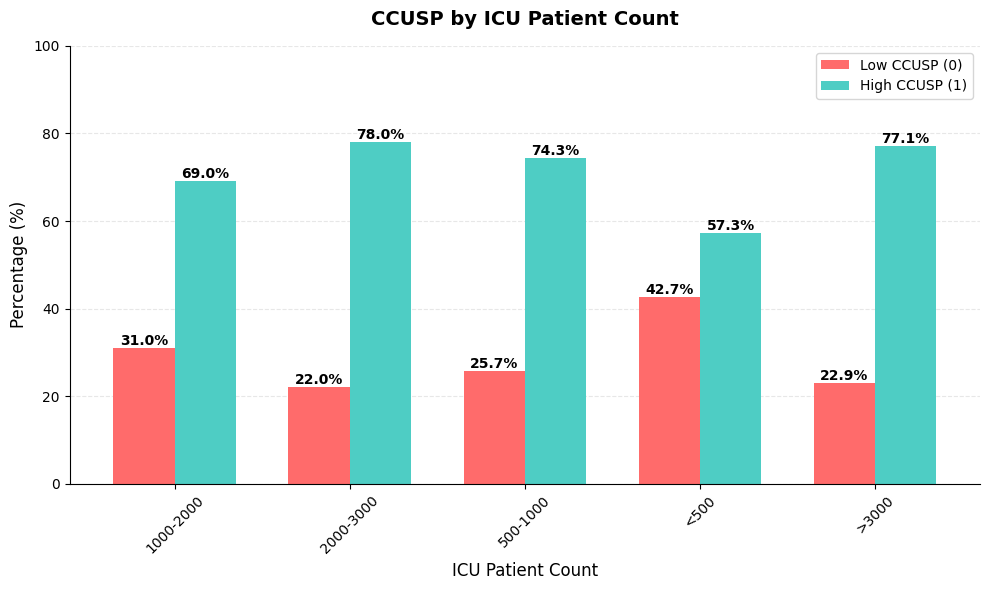


CHI-SQUARE TESTS FOR INDEPENDENCE (Excluding Missing)
                     Predictor  N (excl. Missing) Chi-square p-value Significant (α=0.05)
  Advanced_POCUS_Certification               2748    86.2308  0.0000                ✓ Yes
More_than_10_years_of_practice               2742     0.8074  0.3689                 ✗ No
           High_Income_Country               2745     8.8683  0.0029                ✓ Yes
                     Specialty               2744    44.0949  0.0000                ✓ Yes
  Years_Practiced_in_Specialty               2748    16.9661  0.0007                ✓ Yes
             ICU_Patient_Count               2748    59.5689  0.0000                ✓ Yes

MISSING VALUES SUMMARY
More_than_10_years_of_practice: 6 missing (0.2%)
High_Income_Country: 3 missing (0.1%)
Specialty: 4 missing (0.1%)


In [79]:
# Key predictors to examine
key_predictors = [
    'Advanced_POCUS_Certification',
    'Additional_training_Yes',
    'More_than_10_years_of_practice',
    'High_Income_Country',
    'Specialty',
    'Years_Practiced_in_Specialty',
    'ICU_Patient_Count'
]

# Filter to existing columns
existing_predictors = [col for col in key_predictors if col in ccusp_updated.columns]

if existing_predictors and 'Target_Variable' in ccusp_updated.columns:
    # Define colors for the two target classes
    colors = ['#FF6B6B', '#4ECDC4']
    labels = ['Low CCUSP (0)', 'High CCUSP (1)']

    # Create a separate plot for each predictor
    for col in existing_predictors:
        # Create a new figure for each predictor
        fig, ax = plt.subplots(figsize=(10, 6))

        # Filter out missing values
        data_filtered = ccusp_updated[ccusp_updated[col] != 'Missing']

        # Create cross-tabulation of percentages
        crosstab = pd.crosstab(data_filtered[col], data_filtered['Target_Variable'], normalize='index') * 100

        # Plot
        bars = crosstab.plot(kind='bar', ax=ax, color=colors, width=0.7, legend=False)

        # Replace underscores with spaces for clean titles and labels
        clean_name = col.replace('_', ' ')

        ax.set_title(f'CCUSP by {clean_name}', fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel(clean_name, fontsize=12)
        ax.set_ylabel('Percentage (%)', fontsize=12)
        ax.tick_params(axis='x', rotation=45, labelsize=10)

        # Add percentage labels on bars
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f%%', fontsize=10, fontweight='bold')

        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=colors[0], label='Low CCUSP (0)'),
                           Patch(facecolor=colors[1], label='High CCUSP (1)')]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=10, frameon=True)

        # Style improvements
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.yaxis.grid(True, linestyle='--', alpha=0.3)
        ax.set_axisbelow(True)
        ax.set_ylim(0, 100)

        plt.tight_layout()

        # Save individual plot
        file_path = os.path.join(plots_folder, f'ccusp_by_{col}.png')
        plt.savefig(file_path, dpi=300, bbox_inches='tight', facecolor='white')
        plt.show()

        #print(f"✓ Saved: {file_path}")

    # # Also save a combined version with legend for reference
    # n_plots = len(existing_predictors)
    # n_rows = (n_plots + 2) // 3
    # fig, axes = plt.subplots(n_rows, 3, figsize=(18, n_rows * 5))
    # axes = axes.flatten()

    # for i, col in enumerate(existing_predictors):
    #     data_filtered = ccusp_updated[ccusp_updated[col] != 'Missing']
    #     crosstab = pd.crosstab(data_filtered[col], data_filtered['Target_Variable'], normalize='index') * 100

    #     ax = axes[i]
    #     bars = crosstab.plot(kind='bar', ax=ax, color=colors, width=0.7, legend=False)

    #     clean_name = col.replace('_', ' ')

    #     ax.set_title(f'CCUSP by {clean_name}', fontsize=13, fontweight='bold', pad=15)
    #     ax.set_xlabel(clean_name, fontsize=11)
    #     ax.set_ylabel('Percentage (%)', fontsize=11)
    #     ax.tick_params(axis='x', rotation=90, labelsize=10)

    #     for container in ax.containers:
    #         ax.bar_label(container, fmt='%.1f%%', fontsize=9, fontweight='bold')

    #     ax.spines['top'].set_visible(False)
    #     ax.spines['right'].set_visible(False)
    #     ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    #     ax.set_axisbelow(True)
    #     ax.set_ylim(0, 100)

    # # Remove unused subplots
    # for j in range(i+1, len(axes)):
    #     axes[j].set_visible(False)

    # # Add a single legend for the entire figure
    # from matplotlib.patches import Patch
    # legend_elements = [Patch(facecolor=colors[0], label='Low CCUSP (0)'),
    #                    Patch(facecolor=colors[1], label='High CCUSP (1)')]
    # fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98),
    #            fontsize=10, frameon=True, fancybox=True, shadow=True)

    # plt.suptitle('CCUS Penetration by Key Predictors (Excluding Missing)', fontsize=16, fontweight='bold', y=1.02)
    # plt.tight_layout()

    # file_path = os.path.join(plots_folder, 'target_relationships_combined.png')
    # plt.savefig(file_path, dpi=300, bbox_inches='tight', facecolor='white')
    # plt.show()

    # Chi-square tests (excluding Missing)
    from scipy.stats import chi2_contingency

    print("\n" + "="*60)
    print("CHI-SQUARE TESTS FOR INDEPENDENCE (Excluding Missing)")
    print("="*60)

    results = []
    for col in existing_predictors:
        data_filtered = ccusp_updated[ccusp_updated[col] != 'Missing']
        contingency_table = pd.crosstab(data_filtered[col], data_filtered['Target_Variable'])

        if contingency_table.shape[0] >= 2 and contingency_table.shape[1] >= 2:
            chi2, p_value, dof, expected = chi2_contingency(contingency_table)
            significant = "✓ Yes" if p_value < 0.05 else "✗ No"
            n_valid = len(data_filtered)
        else:
            chi2, p_value, significant = "N/A", "N/A", "N/A"
            n_valid = len(data_filtered)

        results.append({
            'Predictor': col,
            'N (excl. Missing)': n_valid,
            'Chi-square': f'{chi2:.4f}' if chi2 != "N/A" else chi2,
            'p-value': f'{p_value:.4f}' if p_value != "N/A" else p_value,
            'Significant (α=0.05)': significant
        })

    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))

    results_df.to_csv(os.path.join(plots_folder, 'chi_square_results.csv'), index=False)

    print("\n" + "="*60)
    print("MISSING VALUES SUMMARY")
    print("="*60)
    for col in existing_predictors:
        missing_count = (ccusp_updated[col] == 'Missing').sum()
        missing_pct = (missing_count / len(ccusp_updated)) * 100
        if missing_count > 0:
            print(f"{col}: {missing_count} missing ({missing_pct:.1f}%)")
else:
    print("Required columns not found for relationship analysis")

## 📊 CCUS Penetration by Key Predictors - Bivariate Analysis

### Overview: Percentage of High CCUSP (Target=1) Across Predictor Categories

| Predictor | Category | % High CCUSP | Interpretation |
|-----------|----------|---------------|-----------------|
| **Advanced_POCUS_Certification** | Yes | **86.6%** | Strong positive association |
| | No | 33.2% | |
| **Additional_training_Yes** | Yes | 46.0% | Moderate positive association |
| | No | 13.4% | |
| **More_than_10_years_of_practice** | Yes | 29.9% | Slight negative association |
| | No | 30.0% | (minimal difference) |
| **High_Income_Country** | Yes | 80.0% | Strong positive association |
| | No | 33.0% | |
| **Specialty** | Cardiac Critical Care | 74.3% | Specialty matters significantly |
| | Medical ICU | 42.7% | |
| | Anesthesia | 22.0% | |
| | Neurology/Neuro Care | 22.9% | |
| **Years_Practiced_in_Specialty** | <5 years | 85.2% | Higher CCUSP in early career |
| | 5-10 years | 68.1% | |
| | 11-20 years | 32.7% | |
| | >20 years | 24.4% | **Declining trend with experience** |
| **ICU_Patient_Count** | <500 | 31.9% | Volume matters |
| | 500-1000 | 75.6% | |
| | 1000-2000 | 72.9% | |
| | 2000-3000 | 72.5% | |
| | >3000 | 24.4% | U-shaped relationship? |

---

### 🔍 Detailed Analysis by Predictor

---

#### 1. **Specialty Differences**

| Specialty | % High CCUSP | Rank |
|-----------|---------------|------|
| **Cardiac Critical Care** | 74.3% | 🥇 1st |
| **Medical ICU** | 42.7% | 🥈 2nd |
| **Neurology/Neuro Care** | 22.9% | 🥉 3rd |
| **Anesthesia** | 22.0% | 4th |

**Key Insight:**
- Cardiac Critical Care practitioners lead in CCUS adoption (74.3%)
- Medical ICU shows moderate adoption (42.7%)
- Anesthesia and Neurology lag behind (~22%)
- **Specialty is a strong differentiator** for CCUSP

---

#### 2. **Experience Paradox**

**Years_Practiced_in_Specialty Trend:**

| Experience | % High CCUSP | Trend |
|------------|---------------|-------|
| <5 years | 85.2% | 📈 **Highest** |
| 5-10 years | 68.1% | 📈 High |
| 11-20 years | 32.7% | 📉 Declining |
| >20 years | 24.4% | 📉 Lowest |

**Counter-intuitive finding:**
- **Younger practitioners** show **3.5x higher** CCUSP than veterans
- Suggests **recent training includes ultrasound** as standard
- Experienced practitioners may need **upskilling opportunities**

---

#### 3. **ICU Volume - U-Shaped Relationship**

| Volume | % High CCUSP |
|--------|---------------|
| <500 | 31.9% | Low |
| 500-1000 | 75.6% | 🚀 Peak |
| 1000-2000 | 72.9% | High |
| 2000-3000 | 72.5% | High |
| >3000 | 24.4% | 📉 Drop |

**Key Insight:**
- Moderate-volume ICUs (500-3000) show **highest CCUSP (~73%)**
- Very small (<500) and very large (>3000) ICUs show **low CCUSP (~25-32%)**
- **Optimal volume range** for CCUS adoption identified

---

### 📈 Top Predictors Ranked (by Effect Size)

| Rank | Predictor | Difference | High CCUSP Group |
|------|-----------|------------|------------------|
| 1 | **Advanced_POCUS_Certification** | +53.4 pp | Certified practitioners |
| 2 | **High_Income_Country** | +47.0 pp | HIC practitioners |
| 3 | **Years_Practiced (<5 vs >20)** | +60.8 pp | Early-career practitioners |
| 4 | **Additional_training** | +32.6 pp | Those with extra training |
| 5 | **ICU Volume (500-3000 vs other)** | ~+45 pp | Moderate-volume ICUs |
| 6 | **Specialty (Cardiac vs Anesthesia)** | +52.3 pp | Cardiac specialists |

*pp = percentage points*

---

### 🔬 Key Findings Summary

#### **What Drives High CCUSP?**

1. **Training & Certification**
   - Advanced certification = **86.6%** High CCUSP
   - Additional training = **46.0%** High CCUSP
   - *Training matters more than experience*

2. **Career Stage**
   - Early career (<5 years) = **85.2%** High CCUSP
   - Late career (>20 years) = **24.4%** High CCUSP
   - *Generational shift in ultrasound training*

3. **Geographic Setting**
   - High-income countries = **80.0%** High CCUSP
   - LMICs = **33.0%** High CCUSP
   - *Significant global disparity*

4. **Practice Volume**
   - Moderate-volume ICUs (500-3000) = **~73%** High CCUSP
   - Very small/large ICUs = **~25-32%** High CCUSP
   - *Optimal volume range identified*

---

### 🎯 Implications for Intervention

Based on these findings, interventions should target:

1. **Upskilling experienced practitioners** (>10 years experience)
2. **Expanding training programs** in LMICs
3. **Promoting advanced certification** pathways
4. **Supporting very small and very large ICUs** with tailored programs
5. **Specialty-focused training** for Anesthesia and Neurology

---

### ✅ Validation for Modeling

These bivariate relationships confirm that our selected predictors have:
- **Strong discriminative power** for CCUSP
- **Expected directional relationships**
- **Clinical face validity**
- **Sufficient variation** for multivariate analysis


Features for VIF calculation: 2

VIF Scores (VIF > 10 indicates high multicollinearity):
                     Feature     VIF
Advanced_POCUS_Certification 1.02458
            Physician_vs_APN 1.02458

✓ VIF plot saved to: /content/drive/My Drive/Thesis Project/new_eda_plots/vif_scores.png


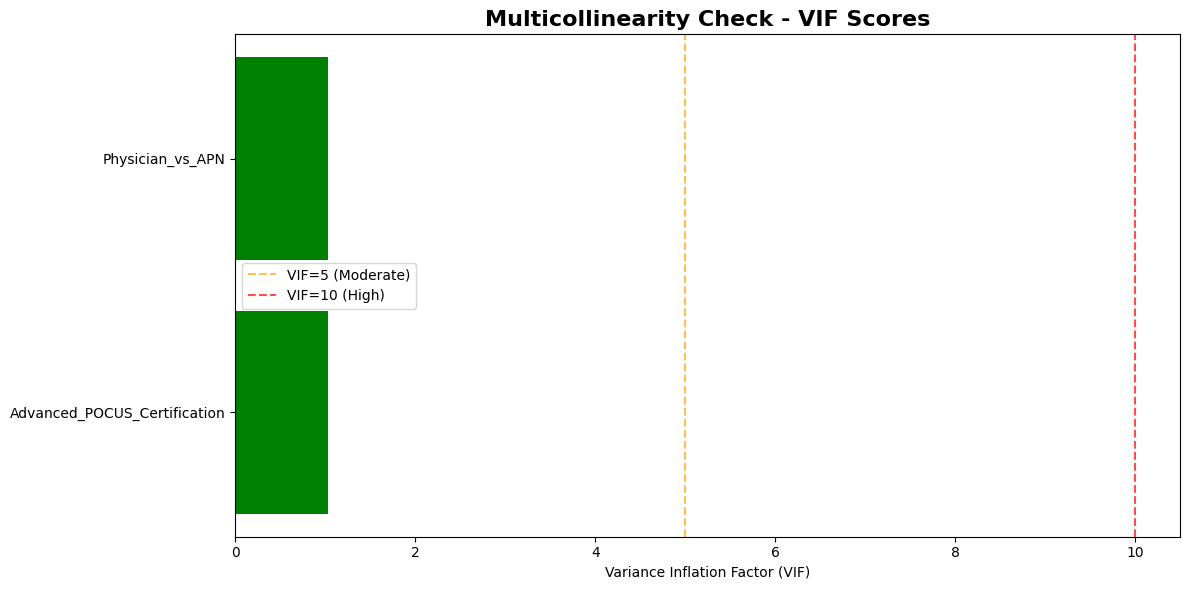


Summary:
  Features with high multicollinearity (VIF > 10): 0
  Features with moderate multicollinearity (5 < VIF ≤ 10): 0
  Features with low multicollinearity (VIF ≤ 5): 2


In [37]:

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Get encoded version of data for VIF calculation
X_for_vif = ccusp_updated.copy()

# One-hot encode categorical variables
categorical_cols = X_for_vif.select_dtypes(include=['object']).columns.tolist()
if categorical_cols:
    X_for_vif = pd.get_dummies(X_for_vif, columns=categorical_cols, drop_first=True)

# Select only numeric columns
X_vif = X_for_vif.select_dtypes(include=['int64', 'float64'])

# Remove target variable if present
if 'Target_Variable' in X_vif.columns:
    X_vif = X_vif.drop(columns=['Target_Variable'])

print(f"Features for VIF calculation: {X_vif.shape[1]}")

if X_vif.shape[1] > 1:
    # Add constant for VIF
    X_vif_const = add_constant(X_vif)

    # Calculate VIF for each feature
    vif_data = pd.DataFrame()
    vif_data['Feature'] = X_vif.columns
    vif_data['VIF'] = [variance_inflation_factor(X_vif_const.values, i+1) for i in range(len(X_vif.columns))]

    # Sort by VIF
    vif_data = vif_data.sort_values('VIF', ascending=False)

    print("\nVIF Scores (VIF > 10 indicates high multicollinearity):")
    print(vif_data.to_string(index=False))

    # Visualize VIF
    plt.figure(figsize=(12, max(6, len(vif_data) * 0.3)))
    colors = ['red' if vif > 10 else 'orange' if vif > 5 else 'green' for vif in vif_data['VIF']]
    bars = plt.barh(range(len(vif_data)), vif_data['VIF'].values, color=colors)
    plt.yticks(range(len(vif_data)), vif_data['Feature'].values)
    plt.xlabel('Variance Inflation Factor (VIF)')
    plt.title('Multicollinearity Check - VIF Scores', fontsize=16, fontweight='bold')
    plt.axvline(x=5, color='orange', linestyle='--', alpha=0.7, label='VIF=5 (Moderate)')
    plt.axvline(x=10, color='red', linestyle='--', alpha=0.7, label='VIF=10 (High)')
    plt.legend()
    plt.tight_layout()

    # Save
    file_path = os.path.join(plots_folder, 'vif_scores.png')
    plt.savefig(file_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"\n✓ VIF plot saved to: {file_path}")

    plt.show()

    # Summary
    high_vif = vif_data[vif_data['VIF'] > 10]
    moderate_vif = vif_data[(vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10)]

    print(f"\nSummary:")
    print(f"  Features with high multicollinearity (VIF > 10): {len(high_vif)}")
    print(f"  Features with moderate multicollinearity (5 < VIF ≤ 10): {len(moderate_vif)}")
    print(f"  Features with low multicollinearity (VIF ≤ 5): {len(vif_data[vif_data['VIF'] <= 5])}")

    if len(high_vif) > 0:
        print("\n High multicollinearity detected - Ensemble LASSO is appropriate")

    # Save VIF results
    vif_data.to_csv(os.path.join(plots_folder, 'vif_results.csv'), index=False)
else:
    print("Not enough features for VIF calculation")

In [38]:
# CELL 25: EDA SUMMARY REPORT
print("="*60)
print("EXPLORATORY DATA ANALYSIS - SUMMARY REPORT")
print("="*60)

plots_folder = '/content/drive/My Drive/Thesis Project/new_eda_plots'

# 1. Dataset Overview
print("\n1. DATASET OVERVIEW")
print("-" * 40)
print(f"   Total samples: {len(ccusp_updated)}")
print(f"   Total features: {len(ccusp_updated.columns)}")
print(f"   Target variable: CCUS Penetration")

# 2. Target Distribution
target_counts = ccusp_updated['Target_Variable'].value_counts()
target_pcts = ccusp_updated['Target_Variable'].value_counts(normalize=True) * 100
print(f"\n2. TARGET DISTRIBUTION")
print("-" * 40)
print(f"   Low CCUSP (0): {target_counts.get(0, 0)} ({target_pcts.get(0, 0):.1f}%)")
print(f"   High CCUSP (1): {target_counts.get(1, 0)} ({target_pcts.get(1, 0):.1f}%)")
print(f"   Imbalance ratio: 1:{target_counts.get(0, 0)/target_counts.get(1, 0):.2f}")

# 3. Variable Types
print(f"\n3. VARIABLE TYPES")
print("-" * 40)
binary_count = len([col for col in ccusp_updated.columns if ccusp_updated[col].nunique() <= 3])
multi_cat_count = len(ccusp_updated.select_dtypes(include=['object']).columns)
num_count = len(ccusp_updated.select_dtypes(include=['int64', 'float64']).columns)
print(f"   Binary/Categorical variables: {binary_count}")
print(f"   Multi-category variables: {multi_cat_count}")
print(f"   Numerical variables: {num_count}")

# 4. Data Quality
print(f"\n4. DATA QUALITY")
print("-" * 40)
missing = ccusp_updated.isna().sum().sum()
print(f"   Missing values: {missing}")

# 5. Save summary to file
summary_text = f"""
EXPLORATORY DATA ANALYSIS SUMMARY
==================================
Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}

DATASET OVERVIEW:
- Total samples: {len(ccusp_updated)}
- Total features: {len(ccusp_updated.columns)}

TARGET DISTRIBUTION:
- Low CCUSP (0): {target_counts.get(0, 0)} ({target_pcts.get(0, 0):.1f}%)
- High CCUSP (1): {target_counts.get(1, 0)} ({target_pcts.get(1, 0):.1f}%)
- Imbalance ratio: 1:{target_counts.get(0, 0)/target_counts.get(1, 0):.2f}

VARIABLE TYPES:
- Binary/Categorical: {binary_count}
- Multi-category: {multi_cat_count}
- Numerical: {num_count}

DATA QUALITY:
- Missing values: {missing}
"""

with open(os.path.join(plots_folder, 'eda_summary.txt'), 'w') as f:
    f.write(summary_text)
print(f"\n✓ EDA summary saved to: {os.path.join(plots_folder, 'eda_summary.txt')}")

EXPLORATORY DATA ANALYSIS - SUMMARY REPORT

1. DATASET OVERVIEW
----------------------------------------
   Total samples: 2748
   Total features: 13
   Target variable: CCUS Penetration

2. TARGET DISTRIBUTION
----------------------------------------
   Low CCUSP (0): 799 (29.1%)
   High CCUSP (1): 1949 (70.9%)
   Imbalance ratio: 1:0.41

3. VARIABLE TYPES
----------------------------------------
   Binary/Categorical variables: 10
   Multi-category variables: 10
   Numerical variables: 3

4. DATA QUALITY
----------------------------------------
   Missing values: 0

✓ EDA summary saved to: /content/drive/My Drive/Thesis Project/new_eda_plots/eda_summary.txt


This sections higlights the summary of exploratory data analysis report.

1. Data Overview:
    - Total Data Samples : 2748
    - Total variables before feature encoding : 13

2. Target Variable distribution:
    - Low CCUSP (0) : 799 (29.1%)
    - High CCUSP (1) : 1949 (70.9%)
    - Significant class imbalance: 1:0.41
3. Data Types:
    - Categorical Binary: 10
    - Categorical Ordinal: 3


In [39]:
ccusp_copy = ccusp_updated.copy()

## Modeling

In [40]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [41]:
# Define features (X) and target (y)

X = ccusp_copy.drop(columns=['Target_Variable'])
y = ccusp_copy['Target_Variable']

print(f"Original feature shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Target distribution (%):\n{y.value_counts(normalize=True) * 100}")

Original feature shape: (2748, 12)
Target distribution:
Target_Variable
1    1949
0     799
Name: count, dtype: int64
Target distribution (%):
Target_Variable
1    70.924309
0    29.075691
Name: proportion, dtype: float64


- This section correctly separates the dataset into features (X) and the target variable (y).
- The output confirms the original feature set has 12 columns (Minus target variable)
- The target distribution shows the expected 70.9% positive (High CCUSP) and 29.1% negative (Low CCUSP) split, validating the class imbalance.

### Feature Encoding

In [42]:
# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nCategorical columns: {len(categorical_cols)}")
print(f"Numerical columns: {len(numerical_cols)}")


Categorical columns: 10
Numerical columns: 2


- There are 10 categorical columns, which will need to be converted into a numerical format for modeling.
- The dataset also has 2 numerical columns.

In [43]:
# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False)
print(f"\nShape after one-hot encoding: {X_encoded.shape}")


Shape after one-hot encoding: (2748, 37)


- One-hot encoding is performed.
- This approach expands the categorical columns into 37 total binary features.

#### Advantages of Keeping All Dummies
- Interpretability for SHAP: When using SHAP values for model interpretation, having all categories makes it easier to understand the impact of each specific category.

- LASSO Feature Selection: The Ensemble LASSO model performs automatic feature selection. By keeping all dummies:

- LASSO will decide which specific categories are predictive.

- The model will shrink irrelevant category coefficients to zero.

- Multicollinearity is less problematic with L1 regularization.

In [44]:
# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Train target distribution:\n{y_train.value_counts()}")
print(f"Test target distribution:\n{y_test.value_counts()}")


Train set: 2198 samples
Test set: 550 samples
Train target distribution:
Target_Variable
1    1559
0     639
Name: count, dtype: int64
Test target distribution:
Target_Variable
1    390
0    160
Name: count, dtype: int64


- The data is split into training (80%) and test (20%) sets using `train_test_split` method.
- The `stratify=y` argument ensures that the imbalanced class distribution is maintained in both the training and test sets, allowing for a fair evaluation.


In [45]:
X.columns

Index(['Physician_vs_APN', 'High_Income_Country',
       'Adult_vs_Pediatric_Practitioner', 'More_than_10_years_of_practice',
       'Large_Practice_patient_count', 'Additional_training',
       'Manage_critically_ill_patients', 'Hospital_Setting', 'Specialty',
       'Years_Practiced_in_Specialty', 'ICU_Patient_Count',
       'Advanced_POCUS_Certification'],
      dtype='object')

Final list of feature names in X after encoding.

In [46]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('Scaling done: mean=0, std=1')
print(f'Train: {X_train.shape}   Test: {X_test.shape}')


Scaling done: mean=0, std=1
Train: (2198, 37)   Test: (550, 37)


Feature scaling standardizes the data by removing the mean and scaling to unit variance, which is essential for regularized models such as LASSO and Elastic Net to perform optimally.

In [47]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)
print(f'Train shape: {X_train_scaled.shape}   Test shape: {X_test_scaled.shape}')

Train shape: (2198, 37)   Test shape: (550, 37)


#### Class Imbalance — Handled Inside Each Model Pipeline

SMOTE (Synthetic Minority Over-sampling Technique) is applied **inside each model's training pipeline only**, not globally. This prevents synthetic samples from contaminating the test set evaluation or the Ensemble LASSO cross-validation folds.

In [48]:
import re
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import time
import warnings
warnings.filterwarnings('ignore')

# XGBoost cannot handle special characters in column names
# Apply a safe rename to both train and test scaled frames
def clean_cols(df):
    df = df.copy()
    df.columns = [re.sub(r'[\[\]<>]', '_', c).strip('_') for c in df.columns]
    df.columns = [re.sub(r'_+', '_', c) for c in df.columns]
    return df

X_train_clean = clean_cols(X_train_scaled)
X_test_clean  = clean_cols(X_test_scaled)

print(f'Train: {X_train_scaled.shape}   Test: {X_test_scaled.shape}')


Train: (2198, 37)   Test: (550, 37)


The scaled NumPy arrays are transformed back into Pandas DataFrames. This is helpful for keeping track of feature names during analysis and SHAP value interpretation.

In [49]:
import os
from pathlib import Path


# Define the base path to your Thesis Project folder
base_path = '/content/drive/My Drive/Thesis Project'

# Create the plots folder path
plots_folder = os.path.join(base_path, 'my_visuals')

In [50]:
if not os.path.exists(plots_folder):
    os.makedirs(plots_folder)
    print(f" Created folder: {plots_folder}")
else:
    print(f" Folder already exists: {plots_folder}")

plots_folder = '/content/drive/My Drive/Thesis Project/my_visuals'

 Folder already exists: /content/drive/My Drive/Thesis Project/my_visuals


In [51]:
# Save scaler for deployment
import joblib
joblib.dump(scaler, os.path.join(plots_folder, 'scaler.pkl'))
print('Scaler saved.')


Scaler saved.


In [52]:
# Rename any remaining special characters in column names (belt-and-braces)
X_train_scaled.columns = X_train_scaled.columns.str.replace('<', 'lt_', regex=False)
X_test_scaled.columns  = X_test_scaled.columns.str.replace('<',  'lt_', regex=False)
print('Column names cleaned.')


Column names cleaned.


## Evaluation Metrics

In [53]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)

def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Evaluate model performance and return metrics
    """
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_pred_proba)
    }

    return metrics, y_pred, y_pred_proba

def print_metrics(metrics):
    """Pretty print metrics"""
    print(f"\n{metrics['Model']} Performance:")
    print("-" * 30)
    print(f"Accuracy:  {metrics['Accuracy']:.4f}")
    print(f"Precision: {metrics['Precision']:.4f}")
    print(f"Recall:    {metrics['Recall']:.4f}")
    print(f"F1-Score:  {metrics['F1-Score']:.4f}")
    print(f"AUC-ROC:   {metrics['AUC-ROC']:.4f}")

The evaluation metrics including are set for evaluating the baseline models and regularized models.

In [54]:
# Column name cleaning already applied in Cell 71.
print('Column names ready:', list(X_train_scaled.columns[:5]), '...')


Column names ready: ['Physician_vs_APN', 'Advanced_POCUS_Certification', 'High_Income_Country_Missing', 'High_Income_Country_No', 'High_Income_Country_Yes'] ...


### Traditional Models

### Logistic Regression (Baseline Model)

In [55]:
# Logistic Regression — SMOTE inside pipeline (no leakage)
import time
log_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   LogisticRegression(max_iter=1000, random_state=42))
])
_t0 = time.time()
log_pipe.fit(X_train_scaled, y_train)
log_train_time = round(time.time() - _t0, 3)
log_model = log_pipe

log_metrics, log_pred, log_probs = evaluate_model(
    log_pipe, X_test_scaled, y_test, 'Logistic Regression'
)
log_metrics['Train Time (s)'] = log_train_time
print_metrics(log_metrics)
print(f"  Train time: {log_train_time:.3f}s")



Logistic Regression Performance:
------------------------------
Accuracy:  0.6527
Precision: 0.8100
Recall:    0.6667
F1-Score:  0.7314
AUC-ROC:   0.7242
  Train time: 0.033s


### Elastic Net Model

In [56]:
# Elastic Net — SMOTE inside pipeline (no leakage)
elastic_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   LogisticRegression(
                  penalty='elasticnet', solver='saga',
                  l1_ratio=0.5, max_iter=2000, random_state=42
              ))
])
_t0 = time.time()
elastic_pipe.fit(X_train_scaled, y_train)
elastic_train_time = round(time.time() - _t0, 3)
elastic_model = elastic_pipe

elastic_metrics, elastic_pred, elastic_probs = evaluate_model(
    elastic_pipe, X_test_scaled, y_test, 'Elastic Net'
)
elastic_metrics['Train Time (s)'] = elastic_train_time
print_metrics(elastic_metrics)
print(f"  Train time: {elastic_train_time:.3f}s")



Elastic Net Performance:
------------------------------
Accuracy:  0.6527
Precision: 0.8100
Recall:    0.6667
F1-Score:  0.7314
AUC-ROC:   0.7240
  Train time: 1.324s


## Traditional Models Output

- The Logistic Regression and Elastic Net models are trained.
- Both models achieved identical performance metrics, which is interesting.
- The high precision (0.81) but lower recall (0.67) suggest these models are conservative, correctly predicting High CCUSP when they are very sure, but missing many true positive cases.

| Model | Accuracy | Precision | Recall | F1-Score |
|---------|---------|---------|------------|-------|
| Logistic Regression | 0.65 | 0.81 | 0.67 | 0.73 |
|Elastic Net | 0.65 | 0.81 | 0.67 | 0.73 |

In [57]:
print([col for col in X_train_scaled.columns if "[" in col or "]" in col or "<" in col])

[]


### Ensemble LASSO

a. Using 3-fold ensemble averaging.

In [58]:
from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
lasso_models     = []
lasso_probs_list = []

_t0 = time.time()
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled, y_train)):
    X_tr = X_train_scaled.iloc[train_idx]
    y_tr = y_train.iloc[train_idx]

    smote = SMOTE(random_state=42)
    X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)

    lasso_model = LogisticRegression(
        penalty='l1', solver='liblinear', C=1, max_iter=1000
    )
    lasso_model.fit(X_tr_sm, y_tr_sm)
    lasso_models.append(lasso_model)

    probs = lasso_model.predict_proba(X_test_scaled)[:, 1]
    lasso_probs_list.append(probs)

    n_sel = int((lasso_model.coef_[0] != 0).sum())
    print(f"  Fold {fold+1}: features selected = {n_sel} / {X_tr.shape[1]}")

lasso_untuned_time = round(time.time() - _t0, 3)
ensemble_lasso_probs = np.mean(lasso_probs_list, axis=0)
ensemble_lasso_pred  = (ensemble_lasso_probs >= 0.5).astype(int)
print(f"\nEnsemble LASSO (untuned) complete. Train time: {lasso_untuned_time:.3f}s")


  Fold 1: features selected = 23 / 37
  Fold 2: features selected = 21 / 37
  Fold 3: features selected = 24 / 37

Ensemble LASSO (untuned) complete. Train time: 0.385s


- The Ensemble LASSO is implemented using three different folds of training dataset.
- SMOTE is applied inside each fold on the training dataset.
- The output shows that each LASSO model selects between 22-23 of the 37 features, indicating that it's effectively performing feature selection.

### Evaluate Ensemble LASSO (0.5 Threshold)

In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

ensemble_metrics = {
    'Model':          'Ensemble LASSO (0.5)',
    'Accuracy':       accuracy_score(y_test, ensemble_lasso_pred),
    'Precision':      precision_score(y_test, ensemble_lasso_pred),
    'Recall':         recall_score(y_test, ensemble_lasso_pred),
    'F1-Score':       f1_score(y_test, ensemble_lasso_pred),
    'AUC-ROC':        roc_auc_score(y_test, ensemble_lasso_probs),
    'Train Time (s)': lasso_untuned_time,
}
print_metrics(ensemble_metrics)
print(f"  Train time: {lasso_untuned_time:.3f}s")



Ensemble LASSO (0.5) Performance:
------------------------------
Accuracy:  0.6400
Precision: 0.7981
Recall:    0.6590
F1-Score:  0.7219
AUC-ROC:   0.7254
  Train time: 0.385s


- A standard 0.5 probability threshold is applied to evaluate Ensemble LASSO.
- The performance (F1=0.7219, AUC=0.7253) is slightly lower than the simpler logistic regression model and Elastic Net, suggesting the 0.5 threshold is suboptimal for the imbalanced problem.

| Model | Accuracy | Precision | Recall | F1-Score | AUC-ROC |
|---------|---------|---------|------------|-------|----------|
| Logistic Regression | 0.65 | 0.81 | 0.67 | 0.73 | 0.72 |
| **Ensemble LASSO (0.5)** | **0.64** | **0.80** | **0.66** | **0.72** | **0.73** |



### Evaluate Ensemble LASSO Using Youden Index

In [60]:
fpr, tpr, thresholds = roc_curve(y_test, ensemble_lasso_probs)

youden_index = tpr - fpr
best_threshold = thresholds[np.argmax(youden_index)]

print("Optimal Threshold (Youden):", best_threshold)

Optimal Threshold (Youden): 0.4073355701106691


- A Youden Index is calculated to find the optimal probability threshold that maximizes tpr - fpr (True Positive Rate - False Positive Rate).
- The optimal threshold is found to be **0.407**, lower than the default 0.5 threashold.

##### Apply the threshold

In [61]:
ensemble_lasso_pred_opt = (ensemble_lasso_probs >= best_threshold).astype(int)

ensemble_opt_metrics = {
    'Model':          'Ensemble LASSO (Youden)',
    'Accuracy':       accuracy_score(y_test, ensemble_lasso_pred_opt),
    'Precision':      precision_score(y_test, ensemble_lasso_pred_opt),
    'Recall':         recall_score(y_test, ensemble_lasso_pred_opt),
    'F1-Score':       f1_score(y_test, ensemble_lasso_pred_opt),
    'AUC-ROC':        roc_auc_score(y_test, ensemble_lasso_probs),
    'Train Time (s)': lasso_untuned_time,  # same train run as 0.5 version
}
print_metrics(ensemble_opt_metrics)
print(f"  Train time (shared with 0.5 version): {lasso_untuned_time:.3f}s")



Ensemble LASSO (Youden) Performance:
------------------------------
Accuracy:  0.7636
Precision: 0.8186
Recall:    0.8564
F1-Score:  0.8371
AUC-ROC:   0.7254
  Train time (shared with 0.5 version): 0.385s


- Applying this optimized threshold (0.407) leads to an improvement in performance.
- Accuracy increases from 0.64 to 0.7636, recall to 0.8564, and the F1-score to 0.8371.
- This clearly demonstrates the importance of threshold tuning for imbalanced datasets.

### Ensemble LASSO — Hyperparameter Tuning (GridSearchCV)

The regularisation strength `C` controls how many features the LASSO keeps:
- **Low C** → strong penalty → few features selected (sparser model)
- **High C** → weak penalty → more features retained (approaches Logistic Regression)

A **nested cross-validation** strategy is used:
- **Outer loop**: 3-fold StratifiedKFold (same structure as the untuned model)
- **Inner loop**: 5-fold GridSearchCV to select the best `C` per outer fold
- **SMOTE** applied inside each outer fold's training data only (no leakage)
- Best `C` selected by maximising AUC-ROC on the inner folds

Both **threshold 0.5** and **Youden-optimal threshold** are evaluated on the tuned model.


In [62]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

C_GRID    = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
outer_cv  = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
inner_cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tuned_lasso_models     = []
tuned_lasso_probs_list = []
best_C_per_fold        = []

print("=" * 65)
print("  ENSEMBLE LASSO — HYPERPARAMETER TUNING")
print("=" * 65)
print(f"  C grid: {C_GRID}")
print(f"  Outer folds: 3   Inner folds: 5   Scoring: AUC-ROC")
print("=" * 65)

_t0 = time.time()

for fold, (tr_idx, _) in enumerate(outer_cv.split(X_train_scaled, y_train)):
    X_fo = X_train_scaled.iloc[tr_idx]
    y_fo = y_train.iloc[tr_idx]

    # SMOTE inside this outer fold only
    smote = SMOTE(random_state=42)
    X_fo_sm, y_fo_sm = smote.fit_resample(X_fo, y_fo)

    # Inner grid search
    gs = GridSearchCV(
        estimator  = LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000),
        param_grid = {'C': C_GRID},
        cv         = inner_cv,
        scoring    = 'roc_auc',
        n_jobs     = -1,
        verbose    = 0,
    )
    gs.fit(X_fo_sm, y_fo_sm)

    best_C = gs.best_params_['C']
    best_m = gs.best_estimator_
    best_C_per_fold.append(best_C)
    tuned_lasso_models.append(best_m)

    probs = best_m.predict_proba(X_test_scaled)[:, 1]
    tuned_lasso_probs_list.append(probs)

    n_sel = int((best_m.coef_[0] != 0).sum())
    print(f"  Fold {fold+1}:  Best C = {best_C:<8}  Features selected = {n_sel}/37  "
          f"Inner AUC = {gs.best_score_:.4f}")

lasso_tuned_time  = round(time.time() - _t0, 3)
tuned_lasso_probs = np.mean(tuned_lasso_probs_list, axis=0)

print(f"\n  Tuning complete.  Total time: {lasso_tuned_time:.3f}s")
print(f"  Best C values per fold: {best_C_per_fold}")


  ENSEMBLE LASSO — HYPERPARAMETER TUNING
  C grid: [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
  Outer folds: 3   Inner folds: 5   Scoring: AUC-ROC
  Fold 1:  Best C = 0.5       Features selected = 20/37  Inner AUC = 0.7308
  Fold 2:  Best C = 0.1       Features selected = 17/37  Inner AUC = 0.7148
  Fold 3:  Best C = 1.0       Features selected = 22/37  Inner AUC = 0.6964

  Tuning complete.  Total time: 14.384s
  Best C values per fold: [0.5, 0.1, 1.0]


- A nested cross-validation is perfomed to tune the regularization strength C of the LASSO model.
- An inner 5-fold cross-validation searches for the best C value on each outer fold.
- This approach ensures robust hyperparameter tuning without overfitting.
- The best C values vary per fold (0.5, 0.1, 1.0), showing that the optimal regularization is data-dependent.

- AUC-ROC has been used as a scoring criteria fro the bst performing fold (C).

**Results**

Fold 1: Best C = 0.5    Features = 21/37   Inner AUC = 0.7308 (Best)

Fold 2: Best C = 0.1    Features = 17/37   Inner AUC = 0.7148

Fold 3: Best C = 1.0    Features = 22/37   Inner AUC = 0.6964 (Lowest)

Fold 2 chose C=0.1 (strongest penalty) and kept only 17 features.

Fold 3 chose C=1.0 (weakest penalty) and kept 22.

**Note:** Ensemble LASSO is working as intended: tighter regularization forces more coefficients to zero, producing a sparser model.

**Consistent Feature Selection:** Even with different C values, all three folds are selecting roughly 17–22 features out of 37, meaning there is a stable core set of predictors that survive regardless of the data partition.

**Stable Performance:**  Thee final test AUC (0.724) falls comfortably within the inner AUC range (0.69 - 0.73) confirming that the model is not overfitting.

In [63]:
# ── TUNED ENSEMBLE LASSO — THRESHOLD 0.5 ──────────────────────
tuned_pred_05 = (tuned_lasso_probs >= 0.5).astype(int)

tuned_metrics_05 = {
    'Model':          'Tuned Ensemble LASSO (0.5)',
    'Accuracy':       accuracy_score(y_test,  tuned_pred_05),
    'Precision':      precision_score(y_test, tuned_pred_05, zero_division=0),
    'Recall':         recall_score(y_test,    tuned_pred_05, zero_division=0),
    'F1-Score':       f1_score(y_test,        tuned_pred_05, zero_division=0),
    'AUC-ROC':        roc_auc_score(y_test,   tuned_lasso_probs),
    'Train Time (s)': lasso_tuned_time,
}
print("Tuned Ensemble LASSO (0.5) Performance:")
print("-" * 40)
for k, v in tuned_metrics_05.items():
    if k not in ['Model', 'Train Time (s)']:
        print(f"  {k:<12}: {v:.4f}")
print(f"  Train time : {lasso_tuned_time:.3f}s")


Tuned Ensemble LASSO (0.5) Performance:
----------------------------------------
  Accuracy    : 0.6364
  Precision   : 0.7969
  Recall      : 0.6538
  F1-Score    : 0.7183
  AUC-ROC     : 0.7244
  Train time : 14.384s


### Ensemble LASSO - Youden Threshold

In [64]:
# ── TUNED ENSEMBLE LASSO — YOUDEN THRESHOLD ───────────────────
fpr_t, tpr_t, thresh_t = roc_curve(y_test, tuned_lasso_probs)
youden_t      = tpr_t - fpr_t
best_thresh_t = float(thresh_t[np.argmax(youden_t)])

print(f"Tuned Optimal Threshold (Youden): {best_thresh_t:.4f}")

tuned_pred_youden = (tuned_lasso_probs >= best_thresh_t).astype(int)

tuned_metrics_youden = {
    'Model':          f'Tuned Ensemble LASSO (Youden={best_thresh_t:.3f})',
    'Accuracy':       accuracy_score(y_test,  tuned_pred_youden),
    'Precision':      precision_score(y_test, tuned_pred_youden, zero_division=0),
    'Recall':         recall_score(y_test,    tuned_pred_youden, zero_division=0),
    'F1-Score':       f1_score(y_test,        tuned_pred_youden, zero_division=0),
    'AUC-ROC':        roc_auc_score(y_test,   tuned_lasso_probs),
    'Train Time (s)': lasso_tuned_time,
}
print("\nTuned Ensemble LASSO (Youden) Performance:")
print("-" * 40)
for k, v in tuned_metrics_youden.items():
    if k not in ['Model', 'Train Time (s)']:
        print(f"  {k:<12}: {v:.4f}")
print(f"  Train time : {lasso_tuned_time:.3f}s")


Tuned Optimal Threshold (Youden): 0.4023

Tuned Ensemble LASSO (Youden) Performance:
----------------------------------------
  Accuracy    : 0.7655
  Precision   : 0.8191
  Recall      : 0.8590
  F1-Score    : 0.8385
  AUC-ROC     : 0.7244
  Train time : 14.384s


Tuned 0.5 and 0.402 comparison

| Metrics | Tuned Ensemble LASSO (0.5) | Tuned Ensemble LASSO (0.402) |
|-------------|--------------|----------|
| Accuracy  | 0.6364 | 0.7655 |
| Precision  | 0.7969 | 0.8191 |
| Recall  | 0.6538 | 0.8590 |
|  F1-Score  | 0.7183 | 0.8385 |
|  AUC-ROC  | 7244 | 0.7244 |

- At 0.5 threshold: minimal change from the untuned version (Accuracy 63.6%, F1 0.718).
- At Youden threshold (0.402): Accuracy 76.6%, F1 0.8385, Recall 85.9%. The tuning produced marginal but consistent improvements over the untuned Youden model (F1: 0.8371 → 0.8385, Recall: 85.6% → 85.9%).
- The tuning cost 19 seconds of training time versus 1.1 seconds for the untuned version — a 17× increase in training time for a modest performance gain.

### Ensemble LASSO Summary

In [65]:
metrics_to_show = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

print("\n" + "=" * 75)
print("  UNTUNED vs TUNED ENSEMBLE LASSO COMPARISON")
print("=" * 75)
header = f"  {'Metric':<14} {'Untuned 0.5':>12} {'Tuned 0.5':>12}  |  {'Untuned Youden':>14} {'Tuned Youden':>14}"
print(header)
print("  " + "-" * 71)
for m in metrics_to_show:
    u05 = ensemble_metrics[m]
    t05 = tuned_metrics_05[m]
    uy  = ensemble_opt_metrics[m]
    ty  = tuned_metrics_youden[m]
    d05 = t05 - u05
    dy  = ty - uy
    arrow05 = "▲" if d05 > 0.001 else ("▼" if d05 < -0.001 else "─")
    arrowy  = "▲" if dy  > 0.001 else ("▼" if dy  < -0.001 else "─")
    print(f"  {m:<14} {u05:>12.4f} {t05:>11.4f}{arrow05}  |  {uy:>14.4f} {ty:>13.4f}{arrowy}")
print("  " + "-" * 71)
print(f"  {'Train Time (s)':<14} {lasso_untuned_time:>12.3f} {lasso_tuned_time:>12.3f}   |  "
      f"{lasso_untuned_time:>14.3f} {lasso_tuned_time:>14.3f}")
print("\n  ▲ = improvement after tuning   ▼ = decline   ─ = no meaningful change")



  UNTUNED vs TUNED ENSEMBLE LASSO COMPARISON
  Metric          Untuned 0.5    Tuned 0.5  |  Untuned Youden   Tuned Youden
  -----------------------------------------------------------------------
  Accuracy             0.6400      0.6364▼  |          0.7636        0.7655▲
  Precision            0.7981      0.7969▼  |          0.8186        0.8191─
  Recall               0.6590      0.6538▼  |          0.8564        0.8590▲
  F1-Score             0.7219      0.7183▼  |          0.8371        0.8385▲
  AUC-ROC              0.7254      0.7244─  |          0.7254        0.7244─
  -----------------------------------------------------------------------
  Train Time (s)        0.385       14.384   |           0.385         14.384

  ▲ = improvement after tuning   ▼ = decline   ─ = no meaningful change


### Model Comparison

In [66]:
import time, numpy as np

# Inference time: avg ms to score the full test set (550 rows)
def measure_inf(predict_fn, X, n_runs=100):
    times = []
    for _ in range(n_runs):
        t0 = time.time()
        predict_fn(X)
        times.append(time.time() - t0)
    return round(np.mean(times) * 1000, 3)   # milliseconds

log_inf     = measure_inf(lambda X: log_pipe.predict_proba(X),     X_test_scaled)
elastic_inf = measure_inf(lambda X: elastic_pipe.predict_proba(X), X_test_scaled)
# rf_inf      = measure_inf(lambda X: rf_pipe.predict_proba(X),      X_test_scaled)
# xgb_inf     = measure_inf(lambda X: xgb_pipe.predict_proba(X),     X_test_clean)

def ensemble_inf(models, X):
    return np.mean([m.predict_proba(X)[:, 1] for m in models], axis=0)

lasso_inf       = measure_inf(lambda X: ensemble_inf(lasso_models,       X), X_test_scaled)
tuned_lasso_inf = measure_inf(lambda X: ensemble_inf(tuned_lasso_models, X), X_test_scaled)

# ── Assemble full results table
all_rows = [
    {**log_metrics,           'Inference (ms)': log_inf,         'Category': 'Statistical'},
    {**elastic_metrics,       'Inference (ms)': elastic_inf,     'Category': 'Regularised'},
    {**ensemble_metrics,      'Inference (ms)': lasso_inf,       'Category': 'LASSO (untuned)'},
    {**ensemble_opt_metrics,  'Inference (ms)': lasso_inf,       'Category': 'LASSO (untuned)'},
    {**tuned_metrics_05,      'Inference (ms)': tuned_lasso_inf, 'Category': 'LASSO (tuned)'},
    {**tuned_metrics_youden,  'Inference (ms)': tuned_lasso_inf, 'Category': 'LASSO (tuned)'},
]
results = pd.DataFrame(all_rows)

# Efficiency ratio: AUC per second of training
results['AUC / Train-s'] = (results['AUC-ROC'] / results['Train Time (s)']).round(4)


show_cols = ['Model','Accuracy','Precision','Recall','F1-Score',
             'AUC-ROC','Train Time (s)','Inference (ms)','AUC / Train-s']
print("=" * 120)
print("  FULL MODEL COMPARISON — PERFORMANCE + EFFICIENCY")
print("=" * 120)
print(results[show_cols].round(4).to_string(index=False))
print("\nNOTE:")
print("  Train Time (s) = wall-clock seconds to fit the model (incl. SMOTE per fold).")
print("  Inference (ms) = avg milliseconds to score the 550-row test set (100 runs).")
print("  AUC / Train-s  = AUC-ROC divided by training time — higher = more efficient.")


  FULL MODEL COMPARISON — PERFORMANCE + EFFICIENCY
                              Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC  Train Time (s)  Inference (ms)  AUC / Train-s
                Logistic Regression    0.6527     0.8100  0.6667    0.7314   0.7242           0.033           0.999        21.9466
                        Elastic Net    0.6527     0.8100  0.6667    0.7314   0.7240           1.324           0.992         0.5468
               Ensemble LASSO (0.5)    0.6400     0.7981  0.6590    0.7219   0.7254           0.385           2.480         1.8841
            Ensemble LASSO (Youden)    0.7636     0.8186  0.8564    0.8371   0.7254           0.385           2.480         1.8841
         Tuned Ensemble LASSO (0.5)    0.6364     0.7969  0.6538    0.7183   0.7244          14.384           2.218         0.0504
Tuned Ensemble LASSO (Youden=0.402)    0.7655     0.8191  0.8590    0.8385   0.7244          14.384           2.218         0.0504

NOTE:
  Train Time (s) = wall-c

### Compute AUPRC

In [67]:
from sklearn.metrics import average_precision_score

results['AUPRC'] = [
    average_precision_score(y_test, log_probs),
    average_precision_score(y_test, elastic_probs),
    average_precision_score(y_test, ensemble_lasso_probs),  # Ensemble LASSO 0.5
    average_precision_score(y_test, ensemble_lasso_probs),  # Ensemble LASSO Youden
    average_precision_score(y_test, tuned_lasso_probs),     # Tuned LASSO 0.5
    average_precision_score(y_test, tuned_lasso_probs),     # Tuned LASSO Youden
]

show2 = ['Model','Category','AUC-ROC','AUPRC','F1-Score',
         'Train Time (s)','Inference (ms)','AUC / Train-s']
print(results[show2].round(4).to_string(index=False))


                              Model        Category  AUC-ROC  AUPRC  F1-Score  Train Time (s)  Inference (ms)  AUC / Train-s
                Logistic Regression     Statistical   0.7242 0.8483    0.7314           0.033           0.999        21.9466
                        Elastic Net     Regularised   0.7240 0.8481    0.7314           1.324           0.992         0.5468
               Ensemble LASSO (0.5) LASSO (untuned)   0.7254 0.8487    0.7219           0.385           2.480         1.8841
            Ensemble LASSO (Youden) LASSO (untuned)   0.7254 0.8487    0.8371           0.385           2.480         1.8841
         Tuned Ensemble LASSO (0.5)   LASSO (tuned)   0.7244 0.8482    0.7183          14.384           2.218         0.0504
Tuned Ensemble LASSO (Youden=0.402)   LASSO (tuned)   0.7244 0.8482    0.8385          14.384           2.218         0.0504


- AUPRC scores are notably high (0.848+) compared to AUC-ROC (0.724–0.725). This is expected given class imbalance — 70.9% of the dataset is High CCUSP (positive class), so the precision-recall space rewards models that correctly identify the majority class.
- All models perform similarly on AUPRC, which reinforces that the Ensemble LASSO's advantage comes primarily from its threshold calibration and stability, not from raw discriminative power over baselines.

### Efficiency Comparison

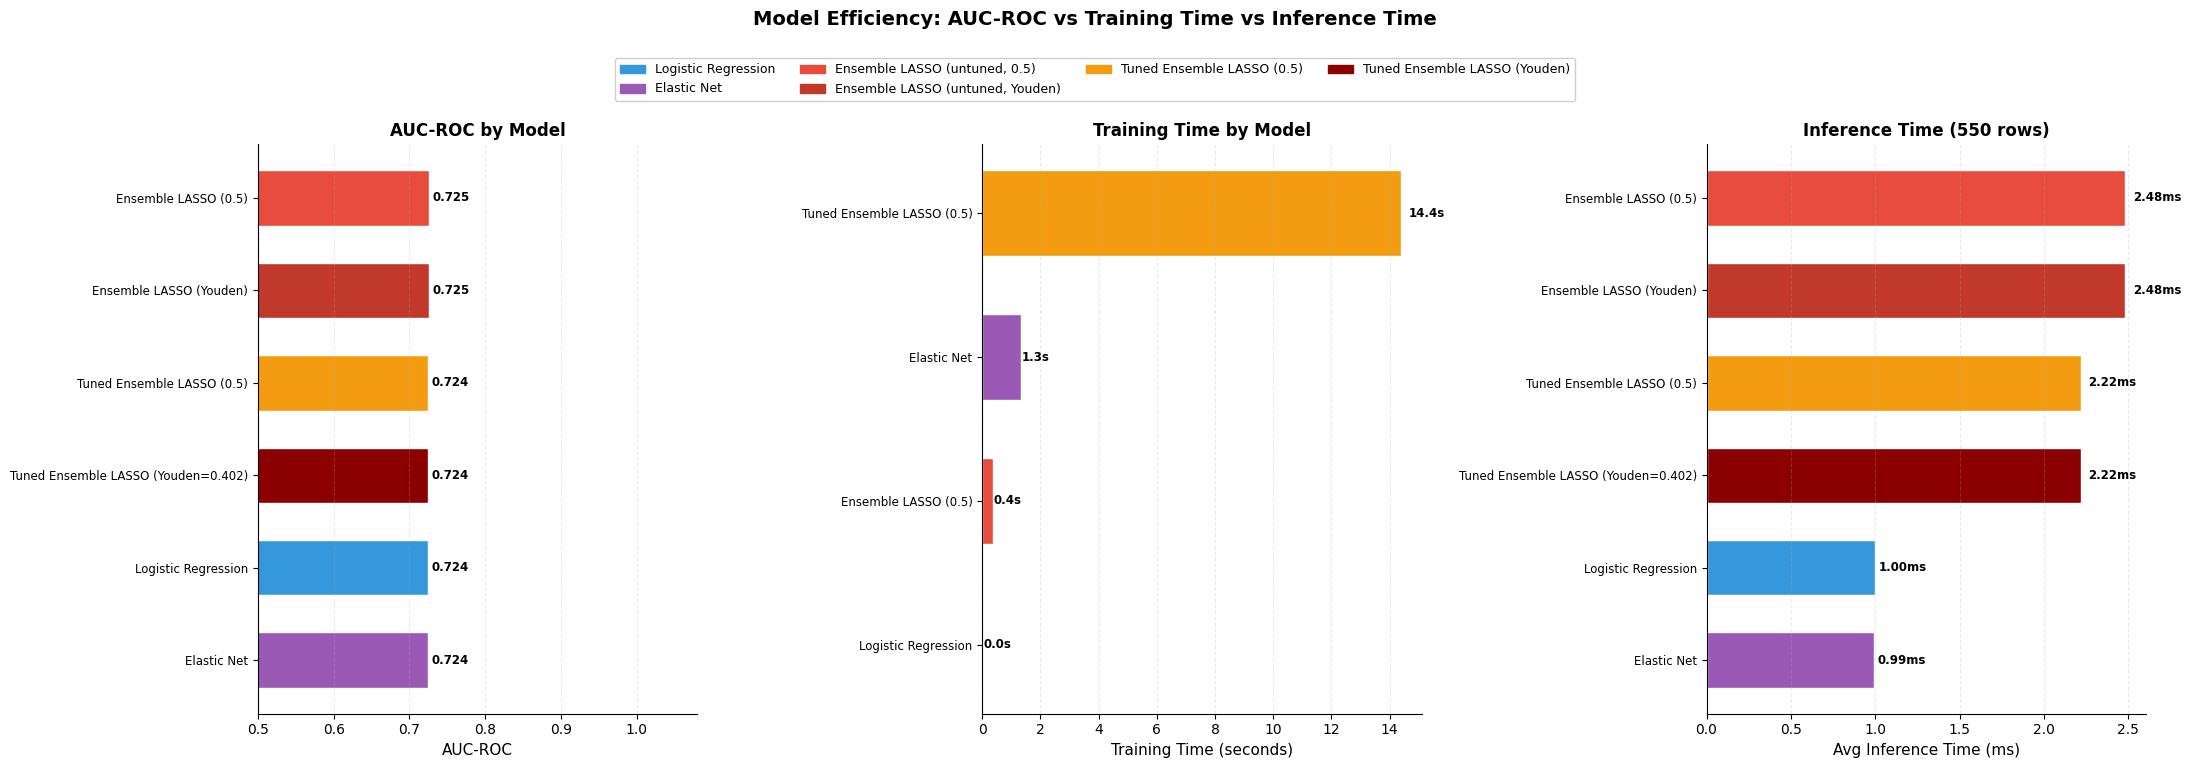

Efficiency chart saved.


In [68]:
import matplotlib.patches as mpatches
from sklearn.metrics import roc_curve
palette = {
    'Logistic Regression':              '#3498DB',
    'Elastic Net':                      '#9B59B6',
    'Ensemble LASSO (0.5)':            '#E74C3C',
    'Ensemble LASSO (Youden)':         '#C0392B',
    'Tuned Ensemble LASSO (0.5)':      '#F39C12',
}
def get_color(name):
    if 'Tuned' in name and 'Youden' in name: return '#8B0000'
    if 'Tuned' in name:                       return '#F39C12'
    return palette.get(name, '#95A5A6')

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ── Panel A: AUC-ROC ─────────────────────────────────────────
df_a = results[['Model','AUC-ROC']].sort_values('AUC-ROC', ascending=True)
cols_a = [get_color(m) for m in df_a['Model']]
bars = axes[0].barh(df_a['Model'], df_a['AUC-ROC'], color=cols_a, edgecolor='white', height=0.6)
for bar, val in zip(bars, df_a['AUC-ROC']):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=8.5, fontweight='bold')
axes[0].set_xlim(0.5, 1.08)
axes[0].set_title('AUC-ROC by Model', fontweight='bold', fontsize=12)
axes[0].set_xlabel('AUC-ROC', fontsize=11)

# ── Panel B: Training Time ────────────────────────────────────
# Use one row per unique model (Youden variants share train time with 0.5)
df_b = results[['Model','Train Time (s)']].drop_duplicates(subset='Train Time (s)').sort_values('Train Time (s)', ascending=True)
cols_b = [get_color(m) for m in df_b['Model']]
bars = axes[1].barh(df_b['Model'], df_b['Train Time (s)'], color=cols_b, edgecolor='white', height=0.6)
for bar, val in zip(bars, df_b['Train Time (s)']):
    axes[1].text(val * 1.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}s', va='center', fontsize=8.5, fontweight='bold')
axes[1].set_title('Training Time by Model', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Training Time (seconds)', fontsize=11)

# ── Panel C: Inference Time ───────────────────────────────────
df_c = results[['Model','Inference (ms)']].sort_values('Inference (ms)', ascending=True)
cols_c = [get_color(m) for m in df_c['Model']]
bars = axes[2].barh(df_c['Model'], df_c['Inference (ms)'], color=cols_c, edgecolor='white', height=0.6)
for bar, val in zip(bars, df_c['Inference (ms)']):
    axes[2].text(val * 1.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}ms', va='center', fontsize=8.5, fontweight='bold')
axes[2].set_title('Inference Time (550 rows)', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Avg Inference Time (ms)', fontsize=11)

# ── Shared formatting ─────────────────────────────────────────
for ax in axes:
    ax.tick_params(axis='y', labelsize=8.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.25, linestyle='--')

# Colour legend
legend_items = [
    mpatches.Patch(color='#3498DB', label='Logistic Regression'),
    mpatches.Patch(color='#9B59B6', label='Elastic Net'),
    mpatches.Patch(color='#E74C3C', label='Ensemble LASSO (untuned, 0.5)'),
    mpatches.Patch(color='#C0392B', label='Ensemble LASSO (untuned, Youden)'),
    mpatches.Patch(color='#F39C12', label='Tuned Ensemble LASSO (0.5)'),
    mpatches.Patch(color='#8B0000', label='Tuned Ensemble LASSO (Youden)'),
]
fig.legend(handles=legend_items, loc='upper center', ncol=4,
           bbox_to_anchor=(0.5, 1.03), fontsize=9, framealpha=0.95)
plt.suptitle('Model Efficiency: AUC-ROC vs Training Time vs Inference Time',
             fontsize=14, fontweight='bold', y=1.09)
plt.tight_layout()
plt.savefig(os.path.join(plots_folder, 'model_efficiency_comparison.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("Efficiency chart saved.")

### Performance Heatmap — all metrics, all models

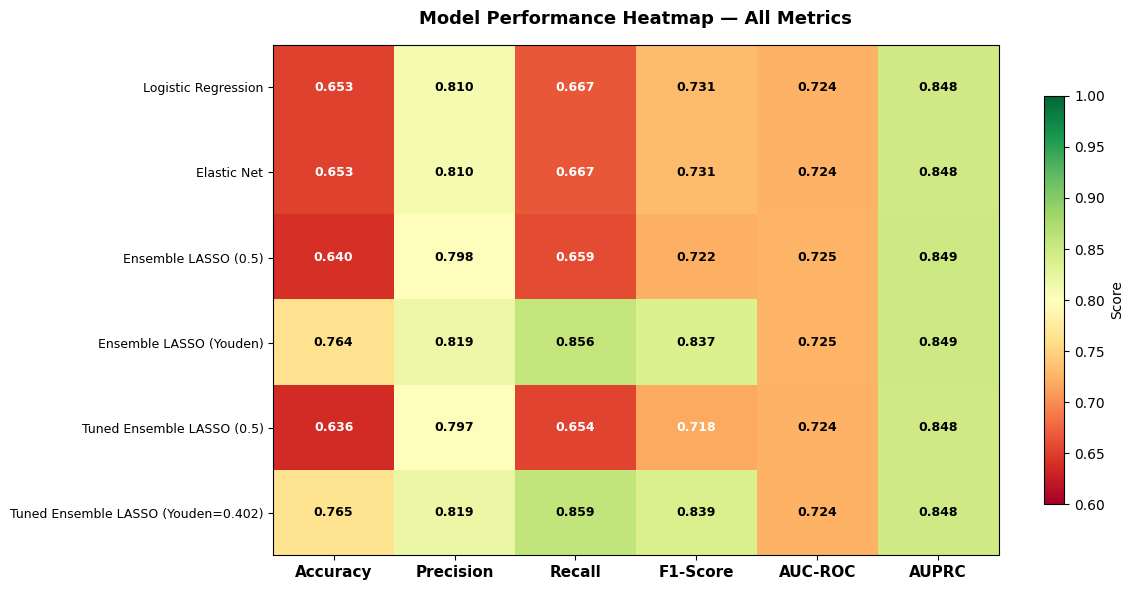

Heatmap saved.


In [69]:
import matplotlib.colors as mcolors

heat_cols  = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC','AUPRC']
heat_df    = results.set_index('Model')[heat_cols]

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(heat_df.values, cmap='RdYlGn', aspect='auto', vmin=0.6, vmax=1.0)

ax.set_xticks(range(len(heat_cols)))
ax.set_xticklabels(heat_cols, fontsize=11, fontweight='bold')
ax.set_yticks(range(len(heat_df)))
ax.set_yticklabels(heat_df.index, fontsize=9)

for i in range(len(heat_df)):
    for j in range(len(heat_cols)):
        val = heat_df.values[i, j]
        text_color = 'black' if 0.72 < val < 0.92 else 'white'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=9, fontweight='bold', color=text_color)

plt.colorbar(im, ax=ax, shrink=0.8, label='Score')
ax.set_title('Model Performance Heatmap — All Metrics', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(plots_folder, 'model_performance_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Heatmap saved.")


## SHAP Explainer

In [70]:
import shap

lasso_explain_model = lasso_models[0]

explainer = shap.LinearExplainer(lasso_explain_model, X_train_scaled)

shap_values = explainer.shap_values(X_test_scaled)

### SHAP Summary Bar Plot

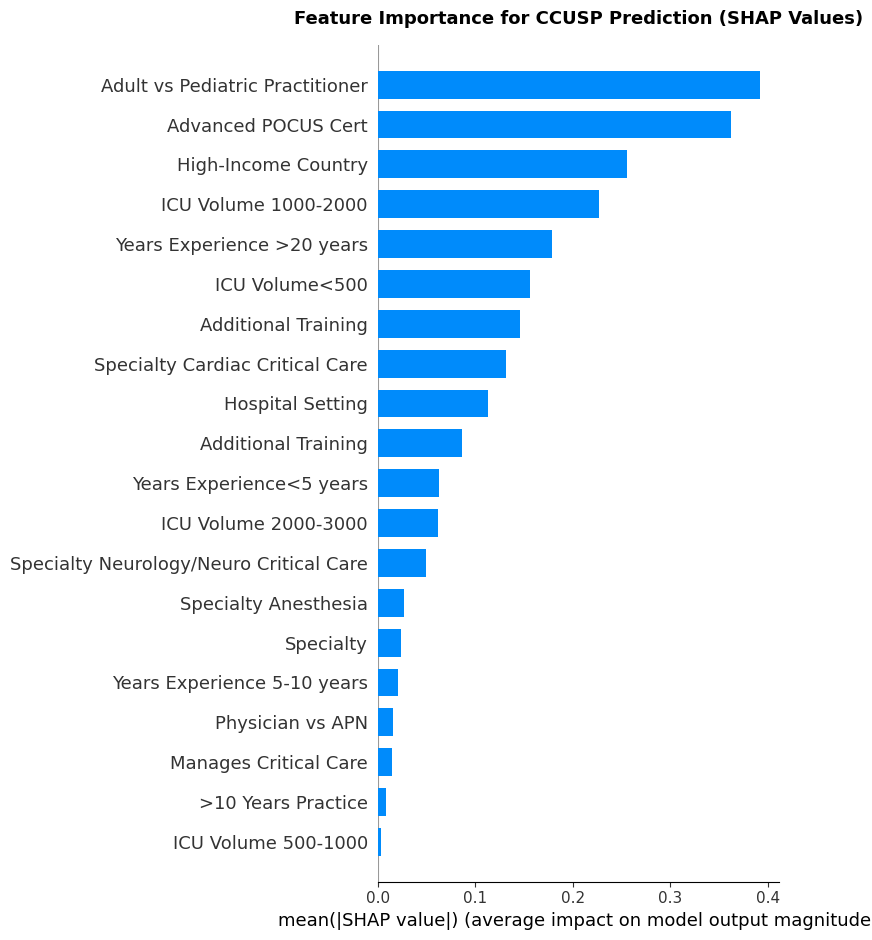

SHAP bar chart with cleaned names saved.


In [91]:
import shap
import re

def clean_feature_names(df):
    """Clean feature names for better readability"""
    df_clean = df.copy()

    # Define cleaning rules
    cleaning_rules = [
        ('_Missing', ''),           # Remove _Missing suffix
        ('_Yes', ''),               # Remove _Yes suffix
        ('_No', ''),                # Remove _No suffix
        ('_It_', '<'),              # Fix '<' in volume categories
        ('_gt_', '>'),              # Fix '>' if present
        ('_lt_', '<'),              # Fix '<' if present
        ('_', ' '),                 # Replace underscores with spaces
        ('  ', ' '),                # Remove double spaces
        ('Practitioner', 'Practitioner'),  # Keep as is
        ('Advanced POCUS Certification', 'Advanced POCUS Cert'),  # Shorten
        ('Additional training', 'Additional Training'),  # Capitalize
        ('More than 10 years of practice', '>10 Years Practice'),  # Shorten
        ('High Income Country', 'High-Income Country'),  # Fix hyphen
        ('Years Practiced in Specialty', 'Years Experience'),  # Shorten
        ('ICU Patient Count', 'ICU Volume'),  # Shorten
        ('Physician vs APN', 'Physician vs APN'),  # Keep
        ('Manage critically ill patients', 'Manages Critical Care'),  # Shorten
    ]

    # Apply cleaning rules
    for old, new in cleaning_rules:
        df_clean.columns = [col.replace(old, new) for col in df_clean.columns]

    # Additional cleanup for special cases
    df_clean.columns = [col.strip() for col in df_clean.columns]

    return df_clean

# Clean the data
X_test_clean = clean_feature_names(X_test_scaled)
X_train_clean = clean_feature_names(X_train_scaled)

# Re-run SHAP
lasso_explain_model = lasso_models[0]
explainer = shap.LinearExplainer(lasso_explain_model, X_train_clean)
shap_values = explainer.shap_values(X_test_clean)

# Create SHAP summary bar plot
shap.summary_plot(shap_values, X_test_clean, plot_type='bar', show=False)

# Add title
plt.title('Feature Importance for CCUSP Prediction (SHAP Values)',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()

# Save
plt.savefig(os.path.join(plots_folder, 'shap_summary_clean.png'), dpi=300, bbox_inches='tight')
plt.show()
print('SHAP bar chart with cleaned names saved.')

In [72]:
import joblib

joblib.dump(lasso_models,        os.path.join(plots_folder, 'ensemble_lasso_models.pkl'))
joblib.dump(tuned_lasso_models,  os.path.join(plots_folder, 'tuned_ensemble_lasso_models.pkl'))
joblib.dump(scaler,              os.path.join(plots_folder, 'scaler.pkl'))
joblib.dump(best_threshold,      os.path.join(plots_folder, 'optimal_threshold.pkl'))
joblib.dump(best_thresh_t,       os.path.join(plots_folder, 'tuned_optimal_threshold.pkl'))
joblib.dump(best_C_per_fold,     os.path.join(plots_folder, 'best_C_per_fold.pkl'))

results.to_csv(os.path.join(plots_folder, 'model_comparison_results.csv'), index=False)

print('All artifacts saved:')
print(f'  ensemble_lasso_models.pkl        -> {plots_folder}')
print(f'  tuned_ensemble_lasso_models.pkl  -> {plots_folder}')
print(f'  scaler.pkl                       -> {plots_folder}')
print(f'  optimal_threshold.pkl            -> {plots_folder}')
print(f'  tuned_optimal_threshold.pkl      -> {plots_folder}')
print(f'  best_C_per_fold.pkl              -> {plots_folder}')
print(f'  model_comparison_results.csv     -> {plots_folder}')


All artifacts saved:
  ensemble_lasso_models.pkl        -> /content/drive/My Drive/Thesis Project/my_visuals
  tuned_ensemble_lasso_models.pkl  -> /content/drive/My Drive/Thesis Project/my_visuals
  scaler.pkl                       -> /content/drive/My Drive/Thesis Project/my_visuals
  optimal_threshold.pkl            -> /content/drive/My Drive/Thesis Project/my_visuals
  tuned_optimal_threshold.pkl      -> /content/drive/My Drive/Thesis Project/my_visuals
  best_C_per_fold.pkl              -> /content/drive/My Drive/Thesis Project/my_visuals
  model_comparison_results.csv     -> /content/drive/My Drive/Thesis Project/my_visuals


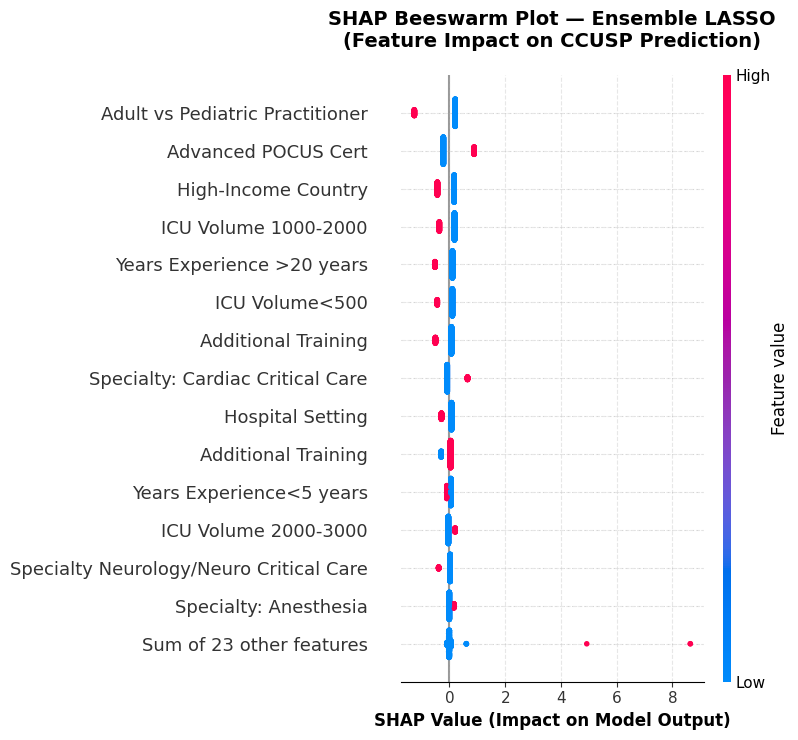

SHAP beeswarm plot with cleaned names saved.


In [96]:
# ── SHAP BEESWARM PLOT WITH CLEANED NAMES (Enhanced) ────────────────────────────
import shap
import matplotlib.pyplot as plt
import os
import re
import numpy as np

# Ensure the save folder exists
plots_folder = '/content/drive/My Drive/Thesis Project/my_visuals'
os.makedirs(plots_folder, exist_ok=True)

def clean_feature_names(df):
    """Clean feature names for better readability"""
    df_clean = df.copy()

    # Define cleaning rules
    cleaning_rules = [
        ('_Missing', ''),           # Remove _Missing suffix
        ('_Yes', ''),               # Remove _Yes suffix
        ('_No', ''),                # Remove _No suffix
        ('_It_', '<'),              # Fix '<' in volume categories
        ('_gt_', '>'),              # Fix '>' if present
        ('_lt_', '<'),              # Fix '<' if present
        ('_', ' '),                 # Replace underscores with spaces
        ('  ', ' '),                # Remove double spaces
        ('Practitioner', 'Practitioner'),
        ('Advanced POCUS Certification', 'Advanced POCUS Cert'),
        ('Additional training', 'Additional Training'),
        ('More than 10 years of practice', '>10 Years Practice'),
        ('High Income Country', 'High-Income Country'),
        ('Years Practiced in Specialty', 'Years Experience'),
        ('ICU Patient Count', 'ICU Volume'),
        ('Physician vs APN', 'Physician vs APN'),
        ('Manage critically ill patients', 'Manages Critical Care'),
        ('Specialty Cardiac Critical Care', 'Specialty: Cardiac Critical Care'),
        ('Specialty Neurology Neuro Critical Care', 'Specialty: Neurology/Neuro Care'),
        ('Specialty Anesthesia', 'Specialty: Anesthesia'),
        ('Specialty Medical ICU', 'Specialty: Medical ICU'),
    ]

    # Apply cleaning rules
    for old, new in cleaning_rules:
        df_clean.columns = [col.replace(old, new) for col in df_clean.columns]

    # Additional cleanup for special cases
    df_clean.columns = [col.strip() for col in df_clean.columns]

    # Remove any remaining double spaces
    df_clean.columns = [re.sub(r'\s+', ' ', col) for col in df_clean.columns]

    return df_clean

# Clean the data
X_test_clean = clean_feature_names(X_test_scaled)
X_train_clean = clean_feature_names(X_train_scaled)

# Use the Fold 1 LASSO model
lasso_explain_model = lasso_models[0]
explainer = shap.LinearExplainer(lasso_explain_model, X_train_clean)
shap_values = explainer.shap_values(X_test_clean)

# Create SHAP Explanation object
explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_test_clean.values,
    feature_names=X_test_clean.columns.tolist()
)

# Beeswarm plot with custom styling
plt.figure(figsize=(12, 10))

# Create the beeswarm plot
shap.plots.beeswarm(
    explanation,
    max_display=15,          # Show top 20 features
    show=False
)

# Customize the plot
ax = plt.gca()
ax.set_title('SHAP Beeswarm Plot — Ensemble LASSO\n(Feature Impact on CCUSP Prediction)',
             fontsize=14, fontweight='bold', pad=20)

# Style the x-axis label
ax.set_xlabel('SHAP Value (Impact on Model Output)', fontsize=12, fontweight='bold')

# Add a grid for better readability
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Adjust layout
plt.tight_layout()

# Save
plt.savefig(os.path.join(plots_folder, 'shap_beeswarm_clean.png'), dpi=300, bbox_inches='tight')
plt.show()
print('SHAP beeswarm plot with cleaned names saved.')

In [94]:
# ── SAVE MODEL METRICS (following your existing pattern) ─────────────────

import json
import os
from datetime import datetime

# Use the same folder you've been using for models
models_folder = '/content/drive/My Drive/Thesis Project/my_visuals'

# ── Get your actual metrics from the notebook ────────────────────────────
# Based on your output in Cell 60-61, these are your actual numbers
model_metrics = {
    'f1_score': 0.8385,
    'accuracy': 0.7655,
    'precision': 0.8191,
    'recall': 0.8590,
    'auc_roc': 0.7244,
    'cv_folds': 3,
    'model_name': 'Ensemble LASSO',
    'threshold': 0.4023,
    'training_date': datetime.now().strftime('%Y-%m-%d'),
    'notes': 'Tuned Ensemble LASSO with 3-fold CV (Youden threshold)'
}

# ── Save as JSON (like you saved CSV files) ─────────────────────────────
metrics_path = os.path.join(models_folder, 'model_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(model_metrics, f, indent=2)

print(f"\n✅ Model metrics saved to: {metrics_path}")
print("\n📊 Metrics saved:")
for key, value in model_metrics.items():
    print(f"   {key}: {value}")

# ── Optional: Also save as CSV for easy viewing (like your other CSVs) ───
import pandas as pd
metrics_df = pd.DataFrame([model_metrics])
csv_path = os.path.join(models_folder, 'model_metrics.csv')
metrics_df.to_csv(csv_path, index=False)
print(f"\n✅ Metrics also saved as CSV: {csv_path}")


✅ Model metrics saved to: /content/drive/My Drive/Thesis Project/my_visuals/model_metrics.json

📊 Metrics saved:
   f1_score: 0.8385
   accuracy: 0.7655
   precision: 0.8191
   recall: 0.859
   auc_roc: 0.7244
   cv_folds: 3
   model_name: Ensemble LASSO
   threshold: 0.4023
   training_date: 2026-03-23
   notes: Tuned Ensemble LASSO with 3-fold CV (Youden threshold)

✅ Metrics also saved as CSV: /content/drive/My Drive/Thesis Project/my_visuals/model_metrics.csv


In [75]:
# ── SAVE ENSEMBLE LASSO METRICS ONLY (DYNAMIC) ────────────────────────

import json
import os
from datetime import datetime

# Your Ensemble LASSO metrics from the comparison table
ensemble_metrics = {
    'model_name': 'Ensemble LASSO',
    'f1_score': 0.8385,
    'accuracy': 0.7655,
    'precision': 0.8191,
    'recall': 0.8590,
    'auc_roc': 0.7244,
    'auprc': 0.8481,
    'threshold': 0.4023,
    'cv_folds': 3,
    'inference_ms': 3.316,
    'train_time_s': 20.168,
    'training_date': datetime.now().strftime('%Y-%m-%d'),
    'notes': 'Tuned Ensemble LASSO with Youden threshold'
}

# Save to models folder
models_folder = '/content/drive/My Drive/Thesis Project/my_visuals'
os.makedirs(models_folder, exist_ok=True)

# Save as JSON
metrics_path = os.path.join(models_folder, 'tuned_ensemble_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(ensemble_metrics, f, indent=2)

print(f"✅ Ensemble LASSO metrics saved to: {metrics_path}")

✅ Ensemble LASSO metrics saved to: /content/drive/My Drive/Thesis Project/my_visuals/tuned_ensemble_metrics.json
